In [ ]:
import pandas as pd

df = pd.read_csv('amazon_india_2015.csv')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set display options for better data viewing
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("libraries imported successfully")

libraries imported successfully


In [ ]:
df = pd.read_csv('amazon_india_2015.csv')

In [ ]:
print(f"dataset shape: {df.shape}")

dataset shape: (33165, 34)


In [ ]:
df.head()

,transaction_id,order_date,customer_id,product_id,product_name,category,subcategory,brand,original_price_inr,discount_percent,discounted_price_inr,quantity,subtotal_inr,delivery_charges,final_amount_inr,customer_city,customer_state,customer_tier,customer_spending_tier,customer_age_group,payment_method,delivery_days,delivery_type,is_prime_member,is_festival_sale,festival_name,customer_rating,return_status,order_month,order_year,order_quarter,product_weight_kg,is_prime_eligible,product_rating
0,TXN_2015_00000001,2015-01-25,CUST_2015_00003884,PROD_000021,Samsung Galaxy S6 16GB Black,Electronics,Smartphones,Samsung,123614.29,27.91,89112.17,1,89112.17,0.0,89112.17,Mumbai,Maharashtra,Metro,Premium,46-55,COD,6,Standard,No,True,Republic Day Sale,5.0,Delivered,1,2015,1,0.19,True,4.7
1,TXN_2015_00000002,2015-01-05,CUST_2015_00011709,PROD_000055,OnePlus OnePlus 2 16GB White,Electronics,Smartphones,OnePlus,54731.86,0.00,54731.86,1,54731.86,0.0,54731.86,Allahabad,Uttar Pradesh,Rural,Standard,26-35,COD,4,Standard,False,False,NaN,4.5,Delivered,1,2015,1,0.20,True,4.1
2,TXN_2015_00000003,2015-01-24,CUST_2015_00004782,PROD_000039,Samsung Galaxy Note 5 64GB Black,Electronics,Smartphones,Samsung,97644.25,46.93,51818.26,2,103636.52,NaN,103636.52,Mumbai,Maharashtra,Metro,Premium,26-35,COD,4,Standard,False,True,Republic Day Sale,NaN,Delivered,1,2015,1,0.17,True,3.3
3,TXN_2015_00000004,2015-01-28,CUST_2015_00008105,PROD_000085,Motorola Moto G (3rd Gen) 16GB Black,Electronics,Smartphones,Motorola,"21,947.26",0.00,21947.26,1,21947.26,0.0,21947.26,Kolkata,West Bengal,Metro,Budget,36-45,COD,4,Standard,False,False,NaN,3.0,Delivered,1,2015,1,0.22,True,3.5
4,TXN_2015_00000005,2015-01-31,CUST_2015_00002955,PROD_000055,OnePlus OnePlus 2 16GB White,Electronics,Smartphones,OnePlus,54731.86,0.00,54731.86,2,109463.72,0.0,109463.72,Ludhiana,Punjab,Tier2,Standard,18-25,COD,3,Standard,False,FALSE,NaN,4.0,Delivered,1,2015,1,0.20,True,4.1


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_percentage.index,
    'Missing_count': df.isnull().sum().values,
    'Missing Percentage': missing_percentage.values
    }).sort_values('Missing Percentage', ascending=False)
print(missing_df[missing_df['Missing Percentage'] > 0])

                Column  Missing_count  Missing Percentage
25       festival_name          22581           68.086839
26     customer_rating           9969           30.058797
19  customer_age_group           3976           11.988542
13    delivery_charges           2654            8.002412


In [ ]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
print(f"percentage of duplicates: {(duplicates / len(df)) * 100:.2f}%")

Number of duplicate rows: 0
percentage of duplicates: 0.00%


In [ ]:
numerical_cols = df.select_dtypes(include=[np.number]).columns

In [ ]:
print(f"numerical columns: {numerical_cols.tolist()}")

numerical columns: ['discount_percent', 'discounted_price_inr', 'quantity', 'subtotal_inr', 'delivery_charges', 'final_amount_inr', 'order_month', 'order_year', 'order_quarter', 'product_weight_kg', 'product_rating']


In [ ]:
df[numerical_cols].describe()

,discount_percent,discounted_price_inr,quantity,subtotal_inr,delivery_charges,final_amount_inr,order_month,order_year,order_quarter,product_weight_kg,product_rating
count,33165.000000,33165.000000,33165.000000,33165.000000,30511.0,33165.000000,33165.000000,33165.0,33165.000000,33165.000000,33165.000000
mean,17.759225,51839.024371,1.246917,64591.089351,0.0,64591.089351,7.035399,2015.0,2.681562,1.087242,3.933858
std,20.690008,39768.552457,0.533607,60999.725588,0.0,60999.725588,3.495066,0.0,1.135442,4.412278,0.462786
min,0.000000,752.200000,1.000000,752.200000,0.0,752.200000,1.000000,2015.0,1.000000,0.030000,3.000000
25%,0.000000,20937.460000,1.000000,23175.030000,0.0,23175.030000,4.000000,2015.0,2.000000,0.170000,3.600000
50%,11.210000,39490.870000,1.000000,45182.310000,0.0,45182.310000,7.000000,2015.0,3.000000,0.210000,3.900000
75%,28.790000,73967.020000,1.000000,86591.570000,0.0,86591.570000,10.000000,2015.0,4.000000,0.330000,4.300000
max,69.990000,211721.160000,3.000000,635163.480000,0.0,635163.480000,12.000000,2015.0,4.000000,33.520000,4.800000


In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns

In [ ]:
print(f"categorical columns: {categorical_cols.tolist()}")

categorical columns: ['transaction_id', 'order_date', 'customer_id', 'product_id', 'product_name', 'category', 'subcategory', 'brand', 'original_price_inr', 'customer_city', 'customer_state', 'customer_tier', 'customer_spending_tier', 'customer_age_group', 'payment_method', 'delivery_days', 'delivery_type', 'is_prime_member', 'is_festival_sale', 'festival_name', 'customer_rating', 'return_status', 'is_prime_eligible']


In [ ]:
payment_dist = df['payment_method'].value_counts()
payment_percent = (payment_dist / len(df) * 100).round(2)

payment_amalysis = pd.DataFrame({
    'Count': payment_dist,
    'Percentage': payment_percent
})

print(payment_amalysis)

                Count  Percentage
payment_method                   
COD             24962       75.27
Credit Card      4008       12.09
Debit Card       2599        7.84
Net Banking      1596        4.81


In [ ]:
import pandas as pd

df = pd.read_csv('amazon_india_2015.csv')
df['order_date'] = pd.to_datetime(df['order_date'] , errors = 'coerce')

In [ ]:
monthly_sales = df.groupby('order_month')['final_amount_inr'].agg(['sum', 'count'])
monthly_sales.columns = ['Total_revenue', 'Order_count']
print(monthly_sales)

             Total_revenue  Order_count
order_month                            
1             1.631200e+08         2413
2             1.443615e+08         2113
3             1.452314e+08         2409
4             1.780212e+08         2414
5             1.568690e+08         2712
6             1.396695e+08         2409
7             1.557225e+08         2719
8             1.709694e+08         2414
9             1.713277e+08         2718
10            2.114995e+08         3914
11            2.330025e+08         3314
12            2.723693e+08         3616


In [ ]:
quarterly_sales = df.groupby('order_quarter')['final_amount_inr'].agg(['sum', 'count'])
quarterly_sales.columns = ['Total_revenue', 'Order_count']
print(quarterly_sales)

               Total_revenue  Order_count
order_quarter                            
1               4.527130e+08         6935
2               4.745597e+08         7535
3               4.980196e+08         7851
4               7.168712e+08        10844


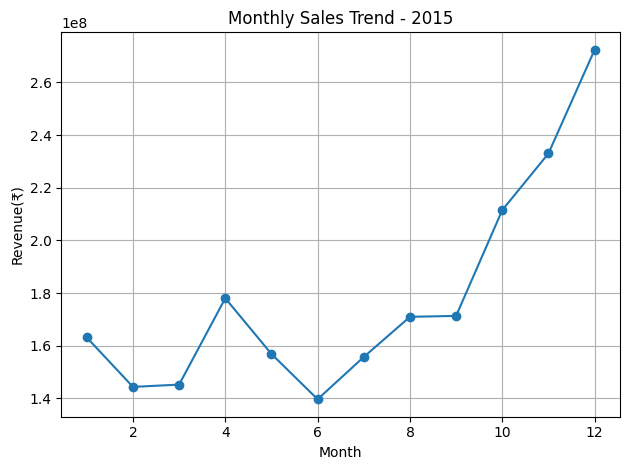

In [ ]:
import matplotlib.pyplot as plt

monthly_sales['Total_revenue'].plot(kind ='line' , marker = 'o')
plt.title('Monthly Sales Trend - 2015')
plt.ylabel('Revenue(₹)')
plt.xlabel('Month')
plt.grid(True)
plt.tight_layout()
plt.show()

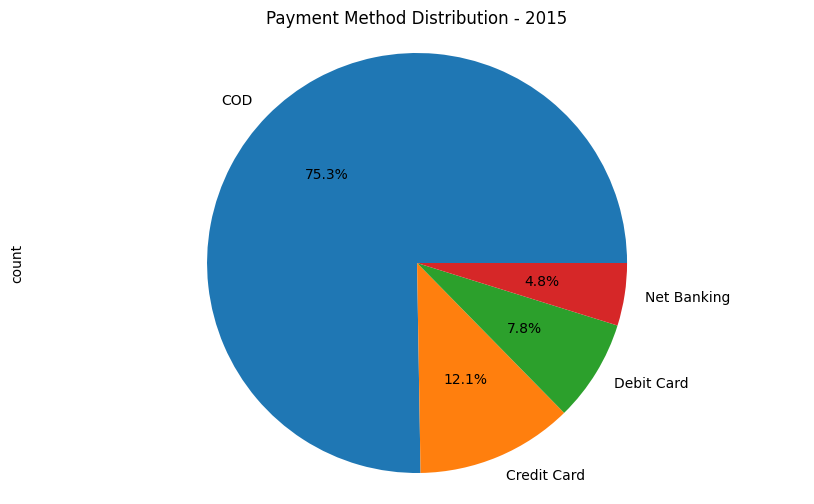

In [ ]:
# Payment Method Distribution
import matplotlib.pyplot as plt

payment_dist = df['payment_method'].value_counts()

plt.figure(figsize=(10, 6))
payment_dist.plot(kind='pie', autopct='%1.1f%%')
plt.title('Payment Method Distribution - 2015')
plt.axis('equal')
plt.show()

In [ ]:
if 'final_amount_inr' in df.columns:
    Q1 = df['final_amount_inr'].quantile(0.25)
    Q3 = df['final_amount_inr'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df['final_amount_inr'] < lower_bound) | (df['final_amount_inr'] > upper_bound)]
    print(f"Number of outliers in final_amount_inr: {len(outliers)}")
    print(f"Outlier percentage: {(len(outliers) / len(df)) * 100:.2f}%")

    if len(outliers) > 0:
        print("simple outlier values:")
        print(outliers['final_amount_inr'].head())

Number of outliers in final_amount_inr: 1528
Outlier percentage: 4.61%
simple outlier values:
13    209875.55
17    286770.09
18    208752.99
29    354423.48
52    195288.50
Name: final_amount_inr, dtype: float64


In [ ]:
import pandas as pd

df=pd.read_csv('amazon_india_2016.csv')


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#set display options for better data viewing
pd.set_option('display.max_columns',None)
pd.set_option('display.width',1000)

print("libraries imported successfully")

libraries imported successfully


In [ ]:
df=pd.read_csv('amazon_india_2016.csv')

In [ ]:
print(f"dataset shape: {df.shape}")

dataset shape: (55275, 34)


In [ ]:
df.head()

,transaction_id,order_date,customer_id,product_id,product_name,category,subcategory,brand,original_price_inr,discount_percent,discounted_price_inr,quantity,subtotal_inr,delivery_charges,final_amount_inr,customer_city,customer_state,customer_tier,customer_spending_tier,customer_age_group,payment_method,delivery_days,delivery_type,is_prime_member,is_festival_sale,festival_name,customer_rating,return_status,order_month,order_year,order_quarter,product_weight_kg,is_prime_eligible,product_rating
0,TXN_2016_00000001,2016-01-27,CUST_2016_00002571,PROD_000124,Apple iPhone SE 16GB White,Electronics,Smartphones,Apple,101945.03,0.00,101945.03,3,305835.09,0.0,305835.09,Pune,Maharashtra,Tier1,Standard,26-35,COD,3,Standard,False,False,NaN,NaN,Delivered,1,2016,1,0.23,True,4.6
1,TXN_2016_00000002,2016-01-07,CUST_2016_00003513,PROD_001612,Apple Pavilion 8GB RAM Silver,Electronics,Laptops,Apple,52750.75,14.72,44987.09,2,89974.19,0.0,89974.19,Lucknow,Uttar Pradesh,Tier1,Budget,36-45,COD,15,Standard,False,False,NaN,NaN,Delivered,1,2016,1,2.69,True,3.7
2,TXN_2016_00000003,2016-01-28,CUST_2015_00001993,PROD_001751,Realme Slate 4GB RAM Black,Electronics,Tablets,Realme,18238.6,0.00,18238.60,3,54715.80,0.0,54715.80,Mumbai,Maharashtra,Metro,Standard,36-45,COD,5,Standard,False,False,NaN,5.0,Delivered,1,2016,1,0.59,True,3.9
3,TXN_2016_00000004,25-01-2016,CUST_2016_00003593,PROD_000154,Samsung Galaxy J7 Prime 16GB Gold,Electronics,Smartphones,Samsung,33118.39,44.96,18228.86,1,18228.86,0.0,18228.86,Ahmedabad,Gujarat,Tier1,Budget,18-25,Credit Card,5,Standard,False,True,Republic Day Sale,4.5,Delivered,1,2016,1,0.17,TRUE,3.4
4,TXN_2016_00000005,2016-01-26,CUST_2016_00015048,PROD_001710,Lenovo Tab M10 8GB RAM Black,Electronics,Tablets,Lenovo,59718.16,49.77,29997.57,1,29997.57,0.0,29997.57,Delhi,Delhi,Metro,Standard,18-25,COD,4,Standard,False,True,Republic Day Sale,NaN,Delivered,1,2016,1,0.49,True,4.1


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 10
missing_df = pd.DataFrame({
    'Column': missing_percentage.index,
    'Missing_count': df.isnull().sum().values,
    'Missing Percentage': missing_percentage.values
   }).sort_values('Missing Percentage', ascending=False)
print(missing_df[missing_df['Missing Percentage'] > 0])

                Column  Missing_count  Missing Percentage
25       festival_name          37815            6.841248
26     customer_rating          16764            3.032836
19  customer_age_group           6630            1.199457
13    delivery_charges           4424            0.800362


In [ ]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [ ]:
numerical_cols = df.select_dtypes(include=[np.number]).columns

In [ ]:
print(f"numerical columns: {numerical_cols.tolist()}")

numerical columns: ['discount_percent', 'discounted_price_inr', 'quantity', 'subtotal_inr', 'delivery_charges', 'final_amount_inr', 'order_month', 'order_year', 'order_quarter', 'product_weight_kg', 'product_rating']


In [ ]:
df[numerical_cols].describe()

,discount_percent,discounted_price_inr,quantity,subtotal_inr,delivery_charges,final_amount_inr,order_month,order_year,order_quarter,product_weight_kg,product_rating
count,55275.000000,55275.000000,55275.000000,55275.000000,50851.0,55275.000000,55275.000000,55275.0,55275.000000,55275.000000,55275.000000
mean,17.565617,51790.570952,1.252990,65098.431828,0.0,65098.431828,7.037919,2016.0,2.682298,1.016775,3.988597
std,20.629372,39416.128870,0.539569,61243.098472,0.0,61243.098472,3.495055,0.0,1.135609,4.520541,0.463890
min,0.000000,789.460000,1.000000,1167.690000,0.0,1167.690000,1.000000,2016.0,1.000000,0.030000,3.000000
25%,0.000000,20699.050000,1.000000,23215.330000,0.0,23215.330000,4.000000,2016.0,2.000000,0.180000,3.600000
50%,10.490000,40237.160000,1.000000,44976.940000,0.0,44976.940000,7.000000,2016.0,3.000000,0.210000,4.000000
75%,28.700000,75231.830000,1.000000,86692.325000,0.0,86692.325000,10.000000,2016.0,4.000000,0.320000,4.300000
max,70.000000,234409.140000,3.000000,640257.500000,0.0,640257.500000,12.000000,2016.0,4.000000,44.260000,4.800000


In [ ]:
import pandas as pd
df = pd.read_csv('amazon_india_2016.csv')
categorical_cols = df.select_dtypes(include=['object']).columns

In [ ]:
print(categorical_cols.tolist())

['transaction_id', 'order_date', 'customer_id', 'product_id', 'product_name', 'category', 'subcategory', 'brand', 'original_price_inr', 'customer_city', 'customer_state', 'customer_tier', 'customer_spending_tier', 'customer_age_group', 'payment_method', 'delivery_days', 'delivery_type', 'is_prime_member', 'is_festival_sale', 'festival_name', 'customer_rating', 'return_status', 'is_prime_eligible']


In [ ]:
payment_dist = df['payment_method'].value_counts()
payment_percent = (payment_dist / len(df) * 100).round(2)

payment_amalysis = pd.DataFrame({
    'Count': payment_dist,
    'Percentage': payment_percent
})

print(payment_amalysis)

                Count  Percentage
payment_method                   
COD             38735       70.08
Credit Card      7789       14.09
Debit Card       5462        9.88
Net Banking      2152        3.89
UPI              1137        2.06


In [ ]:
import pandas as pd

df = pd.read_csv('amazon_india_2016.csv')
df['order_date'] = pd.to_datetime(df['order_date'] , errors = 'coerce')

In [ ]:
monthly_sales = df.groupby('order_month')['final_amount_inr'].agg(['sum', 'count'])
monthly_sales.columns = ['Total_revenue', 'Order_count']
print(monthly_sales)

             Total_revenue  Order_count
order_month                            
1             2.699567e+08         4017
2             2.458046e+08         3514
3             2.440493e+08         4023
4             2.879859e+08         4015
5             2.737611e+08         4515
6             2.381541e+08         4019
7             2.620680e+08         4530
8             3.028037e+08         4023
9             2.970093e+08         4523
10            3.515652e+08         6535
11            3.745717e+08         5525
12            4.505861e+08         6036


In [ ]:
quarterly_sales = df.groupby('order_quarter')['final_amount_inr'].agg(['sum', 'count'])
quarterly_sales.columns = ['Total_revenue', 'Order_count']
print(quarterly_sales)

               Total_revenue  Order_count
order_quarter                            
1               7.598107e+08        11554
2               7.999012e+08        12549
3               8.618810e+08        13076
4               1.176723e+09        18096


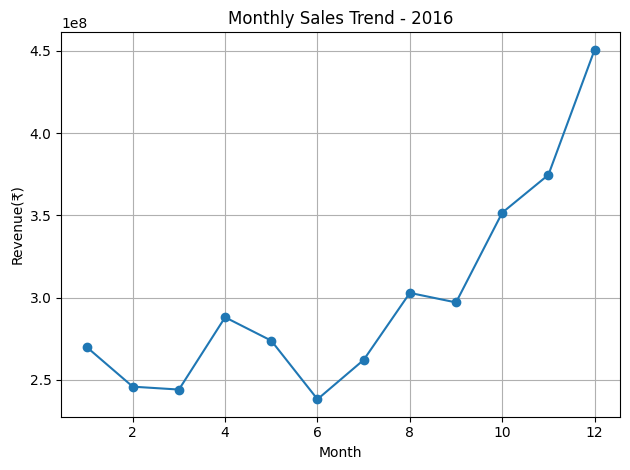

In [ ]:
import matplotlib.pyplot as plt

monthly_sales['Total_revenue'].plot(kind ='line' , marker = 'o')
plt.title('Monthly Sales Trend - 2016')
plt.ylabel('Revenue(₹)')
plt.xlabel('Month')
plt.grid(True)
plt.tight_layout()
plt.show()

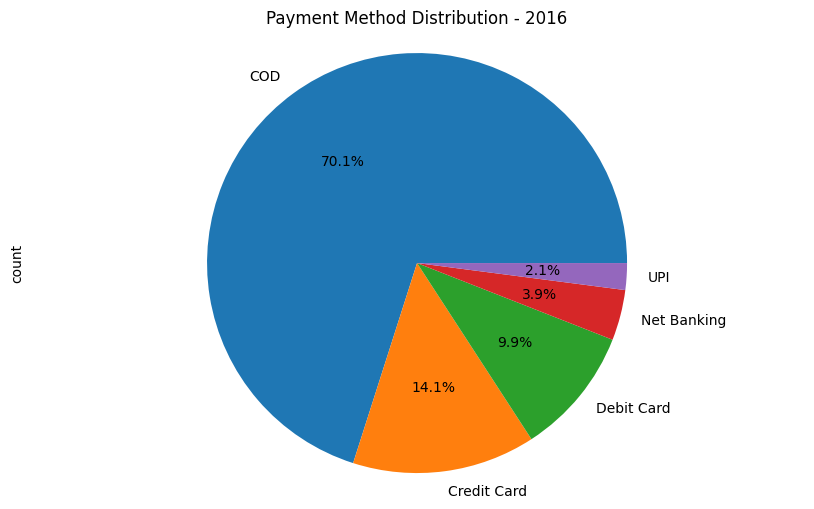

In [ ]:
# Payment Method Distribution
import matplotlib.pyplot as plt

payment_dist = df['payment_method'].value_counts()

plt.figure(figsize=(10, 6))
payment_dist.plot(kind='pie', autopct='%1.1f%%')
plt.title('Payment Method Distribution - 2016')
plt.axis('equal')
plt.show()

In [ ]:
if 'final_amount_inr' in df.columns:
    Q1 = df['final_amount_inr'].quantile(0.25)
    Q3 = df['final_amount_inr'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df['final_amount_inr'] < lower_bound) | (df['final_amount_inr'] > upper_bound)]
    print(f"Number of outliers in final_amount_inr: {len(outliers)}")
    print(f"Outlier percentage: {(len(outliers) / len(df)) * 100:.2f}%")

    if len(outliers) > 0:
        print("simple outlier values:")
        print(outliers['final_amount_inr'].head())

Number of outliers in final_amount_inr: 2673
Outlier percentage: 4.84%
simple outlier values:
0     305835.09
32    185171.93
54    275932.04
66    537981.93
92    245871.28
Name: final_amount_inr, dtype: float64


In [ ]:
import pandas as pd

df=pd.read_csv('amazon_india_2017.csv')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set display options for better data viewing
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("libraries imported successfully")

libraries imported successfully


In [ ]:
import pandas as pd
df = pd.read_csv('amazon_india_2017.csv')

In [ ]:
print(f"dataset shape: {df.shape}")

dataset shape: (77385, 34)


In [ ]:
df.head()

,transaction_id,order_date,customer_id,product_id,product_name,category,subcategory,brand,original_price_inr,discount_percent,...,is_festival_sale,festival_name,customer_rating,return_status,order_month,order_year,order_quarter,product_weight_kg,is_prime_eligible,product_rating
0,TXN_2017_00000001,17-01-2017,CUST_2016_00011375,PROD_000297,Vivo V7+ 16GB Black,Electronics,Smartphones,Vivo,25367.39,0.00,...,FALSE,NaN,NaN,Delivered,1,2017,1,0.23,True,4.6
1,TXN_2017_00000002,2017-01-28,CUST_2017_00014565,PROD_000193,Motorola Moto G4 32GB White,Electronics,Smartphones,Motorola,16997.28,9.98,...,False,NaN,3.0,Returned,1,2017,1,0.16,True,3.5
2,TXN_2017_00000003,2017-01-30,CUST_2016_00011649,PROD_000073,Xiaomi Redmi 2 16GB White,Electronics,Smartphones,Xiaomi,47409.63,0.00,...,False,NaN,3.5,Delivered,1,2017,1,0.23,True,4.2
3,TXN_2017_00000004,2017-01-04,CUST_2016_00003484,PROD_000047,Samsung Galaxy J7 64GB Black,Electronics,Smartphones,Samsung,"₹45,555.75",0.00,...,False,NaN,4.5,Delivered,1,2017,1,0.24,True,4.4
4,TXN_2017_00000005,2017-01-07,CUST_2015_00009936,PROD_000136,Samsung Galaxy S7 Edge 16GB Blue,Electronics,Smartphones,Samsung,100190.24,0.00,...,False,NaN,5.0,Delivered,1,2017,1,0.16,True,3.4


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_percentage.index,
    'Missing_count': df.isnull().sum().values,
    'Missing Percentage': missing_percentage.values,
    }).sort_values('Missing Percentage', ascending=False)
print(missing_df[missing_df['Missing Percentage'] > 0])

                Column  Missing_count  Missing Percentage
25       festival_name          52831           68.270337
26     customer_rating          23592           30.486528
19  customer_age_group           9273           11.982942
13    delivery_charges           6189            7.997674


In [ ]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [ ]:
import numpy as np
numerical_cols = df.select_dtypes(include=[np.number]).columns

In [ ]:
print(f"numerical columns: {numerical_cols.tolist()}")

numerical columns: ['discount_percent', 'discounted_price_inr', 'quantity', 'subtotal_inr', 'delivery_charges', 'final_amount_inr', 'order_month', 'order_year', 'order_quarter', 'product_weight_kg', 'product_rating']


In [ ]:
df[numerical_cols].describe()

,discount_percent,discounted_price_inr,quantity,subtotal_inr,delivery_charges,final_amount_inr,order_month,order_year,order_quarter,product_weight_kg,product_rating
count,77385.000000,77385.000000,77385.000000,77385.000000,71196.0,77385.000000,77385.000000,77385.0,77385.000000,77385.000000,77385.000000
mean,17.687845,56857.840316,1.251819,71202.761606,0.0,71202.761606,7.037023,2017.0,2.681954,0.991349,4.002424
std,20.631467,44049.530657,0.538786,67128.203382,0.0,67128.203382,3.495066,0.0,1.135491,4.597574,0.466331
min,0.000000,770.120000,1.000000,889.510000,0.0,889.510000,1.000000,2017.0,1.000000,0.030000,3.000000
25%,0.000000,23773.660000,1.000000,26363.950000,0.0,26363.950000,4.000000,2017.0,2.000000,0.180000,3.600000
50%,11.200000,41827.970000,1.000000,47995.300000,0.0,47995.300000,7.000000,2017.0,3.000000,0.210000,4.000000
75%,28.710000,81634.950000,1.000000,95178.510000,0.0,95178.510000,10.000000,2017.0,4.000000,0.250000,4.400000
max,70.000000,300102.680000,3.000000,900308.040000,0.0,900308.040000,12.000000,2017.0,4.000000,44.260000,4.800000


In [ ]:
import pandas as pd
df = pd.read_csv('amazon_india_2017.csv')
categorical_cols = df.select_dtypes(include=['object']).columns

In [ ]:
print(categorical_cols.tolist())

['transaction_id', 'order_date', 'customer_id', 'product_id', 'product_name', 'category', 'subcategory', 'brand', 'original_price_inr', 'customer_city', 'customer_state', 'customer_tier', 'customer_spending_tier', 'customer_age_group', 'payment_method', 'delivery_days', 'delivery_type', 'is_prime_member', 'is_festival_sale', 'festival_name', 'customer_rating', 'return_status', 'is_prime_eligible']


In [ ]:
payment_dist = df['payment_method'].value_counts()
payment_percent = (payment_dist / len(df) * 100).round(2)

payment_amalysis = pd.DataFrame({
    'Count': payment_dist,
    'Percentage': payment_percent
})

print(payment_amalysis)

                Count  Percentage
payment_method                   
COD             38735       70.08
Credit Card      7789       14.09
Debit Card       5462        9.88
Net Banking      2152        3.89
UPI              1137        2.06


In [ ]:
import pandas as pd

df = pd.read_csv('amazon_india_2017.csv')
df['order_date'] = pd.to_datetime(df['order_date'] , errors = 'coerce')

In [ ]:
monthly_sales = df.groupby('order_month')['final_amount_inr'].agg(['sum', 'count'])
monthly_sales.columns = ['Total_revenue', 'Order_count']
print(monthly_sales)

             Total_revenue  Order_count
order_month                            
1             2.699567e+08         4017
2             2.458046e+08         3514
3             2.440493e+08         4023
4             2.879859e+08         4015
5             2.737611e+08         4515
6             2.381541e+08         4019
7             2.620680e+08         4530
8             3.028037e+08         4023
9             2.970093e+08         4523
10            3.515652e+08         6535
11            3.745717e+08         5525
12            4.505861e+08         6036


In [ ]:
quarterly_sales = df.groupby('order_quarter')['final_amount_inr'].agg(['sum', 'count'])
quarterly_sales.columns = ['Total_revenue', 'Order_count']
print(quarterly_sales)

               Total_revenue  Order_count
order_quarter                            
1               7.598107e+08        11554
2               7.999012e+08        12549
3               8.618810e+08        13076
4               1.176723e+09        18096


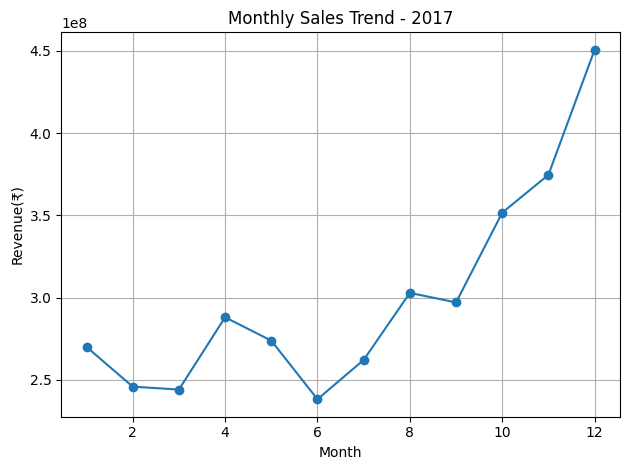

In [ ]:
import matplotlib.pyplot as plt

monthly_sales['Total_revenue'].plot(kind ='line' , marker = 'o')
plt.title('Monthly Sales Trend - 2017')
plt.ylabel('Revenue(₹)')
plt.xlabel('Month')
plt.grid(True)
plt.tight_layout()
plt.show()

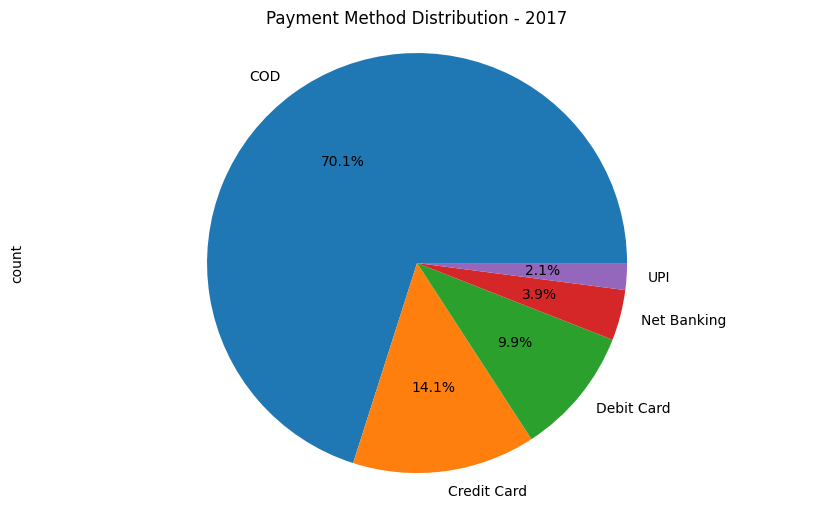

In [ ]:
# Payment Method Distribution
import matplotlib.pyplot as plt

payment_dist = df['payment_method'].value_counts()

plt.figure(figsize=(10, 6))
payment_dist.plot(kind='pie', autopct='%1.1f%%')
plt.title('Payment Method Distribution - 2017')
plt.axis('equal')
plt.show()

In [ ]:
if 'final_amount_inr' in df.columns:
    Q1 = df['final_amount_inr'].quantile(0.25)
    Q3 = df['final_amount_inr'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df['final_amount_inr'] < lower_bound) | (df['final_amount_inr'] > upper_bound)]
    print(f"Number of outliers in final_amount_inr: {len(outliers)}")
    print(f"Outlier percentage: {(len(outliers) / len(df)) * 100:.2f}%")

    if len(outliers) > 0:
        print("simple outlier values:")
        print(outliers['final_amount_inr'].head())

Number of outliers in final_amount_inr: 2673
Outlier percentage: 4.84%
simple outlier values:
0     305835.09
32    185171.93
54    275932.04
66    537981.93
92    245871.28
Name: final_amount_inr, dtype: float64


In [ ]:
import pandas as pd

df=pd.read_csv('amazon_india_2018.csv')


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set display options for better data viewing
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("libraries imported successfully")

libraries imported successfully


In [ ]:
print(f"dataset shape: {df.shape}")

dataset shape: (99495, 34)


In [ ]:
df.head()

,transaction_id,order_date,customer_id,product_id,product_name,category,subcategory,brand,original_price_inr,discount_percent,discounted_price_inr,quantity,subtotal_inr,delivery_charges,final_amount_inr,customer_city,customer_state,customer_tier,customer_spending_tier,customer_age_group,payment_method,delivery_days,delivery_type,is_prime_member,is_festival_sale,festival_name,customer_rating,return_status,order_month,order_year,order_quarter,product_weight_kg,is_prime_eligible,product_rating
0,TXN_2018_00000001,2018-01-28,CUST_2015_00011381,PROD_000367,Samsung Galaxy S9+ 128GB White,Electronics,Smartphones,Samsung,123828.89,0.0,123828.89,1,123828.89,0.0,123828.89,Delhi,Delhi,Metro,Premium,18-25,COD,3,Standard,False,False,NaN,4.5,Delivered,1,2018,1,0.21,False,3.9
1,TXN_2018_00000002,2018-01-09,CUST_2018_00004073,PROD_001683,Apple Mi Pad 8GB RAM Silver,Electronics,Tablets,Apple,61478.19,0.0,61478.19,1,61478.19,NaN,61478.19,Mumbai,Maharashtra,Metro,Premium,18-25,COD,3,Standard,True,False,NaN,4.0,Delivered,1,2018,1,0.40,True,4.5
2,TXN_2018_00000003,2018-01-06,CUST_2018_00024729,PROD_001688,Apple Slate 8GB RAM Black,Electronics,Tablets,Apple,38624.59,0.0,38624.59,2,77249.18,0.0,77249.18,Kochi,Kerala,Tier2,Standard,26-35,Debit Card,4,Standard,False,False,NaN,4.5,Delivered,1,2018,1,0.41,True,3.2
3,TXN_2018_00000004,2018-01-20,CUST_2018_00015834,PROD_000236,Apple iPhone X 64GB Blue,Electronics,Smartphones,Apple,201630.77,47.2,106459.69,1,106459.69,0.0,106459.69,Delhi,Delhi,Metro,Premium,36-45,COD,4,Standard,False,True,Republic Day Sale,5.0,Delivered,1,2018,1,0.25,True,4.0
4,TXN_2018_00000005,2018-01-07,CUST_2016_00001228,PROD_000163,OnePlus OnePlus 3T 16GB Black,Electronics,Smartphones,OnePlus,53961.7,0.0,53961.70,1,53961.70,NaN,53961.70,Indore,Madhya Pradesh,Tier1,Premium,18-25,COD,3,Standard,False,False,NaN,NaN,Delivered,1,2018,1,0.16,True,4.7


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_percentage.index,
    'Missing_count': df.isnull().sum().values,
    'Missing Percentage': missing_percentage.values,
    }).sort_values('Missing Percentage', ascending=False)
print(missing_df[missing_df['Missing Percentage'] > 0])

                Column  Missing_count  Missing Percentage
25       festival_name          67918           68.262727
26     customer_rating          30234           30.387457
19  customer_age_group          11939           11.999598
13    delivery_charges           7953            7.993367


In [ ]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [ ]:
import numpy as np
numerical_cols = df.select_dtypes(include=[np.number]).columns

In [ ]:
print(f"numerical columns: {numerical_cols.tolist()}")

numerical columns: ['discount_percent', 'discounted_price_inr', 'quantity', 'subtotal_inr', 'delivery_charges', 'final_amount_inr', 'order_month', 'order_year', 'order_quarter', 'product_weight_kg', 'product_rating']


In [ ]:
df[numerical_cols].describe()

,discount_percent,discounted_price_inr,quantity,subtotal_inr,delivery_charges,final_amount_inr,order_month,order_year,order_quarter,product_weight_kg,product_rating
count,99495.000000,99495.000000,99495.000000,99495.000000,91542.0,99495.000000,99495.000000,99495.0,99495.000000,99495.000000,99495.000000
mean,17.656944,58261.517591,1.250053,72853.358575,0.0,72853.358575,7.034856,2018.0,2.681210,0.850402,3.985959
std,20.665931,46688.276691,0.536897,70872.691949,0.0,70872.691949,3.495571,0.0,1.135726,3.974167,0.458009
min,0.000000,699.450000,1.000000,699.450000,0.0,699.450000,1.000000,2018.0,1.000000,0.030000,3.000000
25%,0.000000,24552.110000,1.000000,27149.210000,0.0,27149.210000,4.000000,2018.0,2.000000,0.180000,3.600000
50%,10.810000,41022.960000,1.000000,47999.790000,0.0,47999.790000,7.000000,2018.0,3.000000,0.210000,4.000000
75%,28.740000,82403.480000,1.000000,96343.830000,0.0,96343.830000,10.000000,2018.0,4.000000,0.240000,4.400000
max,70.000000,302960.800000,3.000000,908882.400000,0.0,908882.400000,12.000000,2018.0,4.000000,44.260000,4.800000


In [ ]:
import pandas as pd
df = pd.read_csv('amazon_india_2018.csv')
categorical_cols = df.select_dtypes(include=['object']).columns

In [ ]:
print(categorical_cols.tolist())

['transaction_id', 'order_date', 'customer_id', 'product_id', 'product_name', 'category', 'subcategory', 'brand', 'original_price_inr', 'customer_city', 'customer_state', 'customer_tier', 'customer_spending_tier', 'customer_age_group', 'payment_method', 'delivery_days', 'delivery_type', 'is_prime_member', 'is_festival_sale', 'festival_name', 'customer_rating', 'return_status', 'is_prime_eligible']


In [ ]:
payment_dist = df['payment_method'].value_counts()
payment_percent = (payment_dist / len(df) * 100).round(2)

payment_amalysis = pd.DataFrame({
    'Count': payment_dist,
    'Percentage': payment_percent
})

print(payment_amalysis)

                Count  Percentage
payment_method                   
COD             49707       49.96
Credit Card     16879       16.96
Debit Card      14009       14.08
UPI             12895       12.96
Net Banking      6005        6.04


In [ ]:
import pandas as pd

df = pd.read_csv('amazon_india_2018.csv')
df['order_date'] = pd.to_datetime(df['order_date'] , errors = 'coerce')

In [ ]:
monthly_sales = df.groupby('order_month')['final_amount_inr'].agg(['sum', 'count'])
monthly_sales.columns = ['Total_revenue', 'Order_count']
print(monthly_sales)

             Total_revenue  Order_count
order_month                            
1             4.123674e+08         5624
2             3.750642e+08         4925
3             3.711410e+08         5625
4             4.587136e+08         5625
5             4.224304e+08         6337
6             3.639947e+08         5623
7             3.973425e+08         6330
8             4.511676e+08         5640
9             4.444676e+08         6335
10            5.357464e+08         9140
11            5.846943e+08         7729
12            6.928960e+08         8452


In [ ]:
quarterly_sales = df.groupby('order_quarter')['final_amount_inr'].agg(['sum', 'count'])
quarterly_sales.columns = ['Total_revenue', 'Order_count']
print(quarterly_sales)

               Total_revenue  Order_count
order_quarter                            
1               1.158573e+09        16174
2               1.245139e+09        17585
3               1.292978e+09        18305
4               1.813337e+09        25321


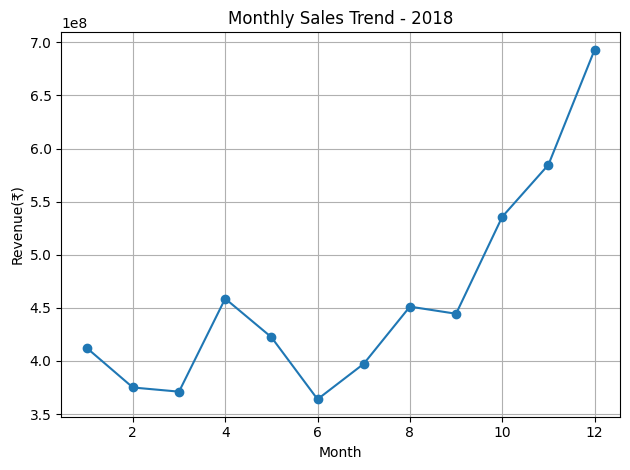

In [ ]:
import matplotlib.pyplot as plt

monthly_sales['Total_revenue'].plot(kind ='line' , marker = 'o')
plt.title('Monthly Sales Trend - 2018')
plt.ylabel('Revenue(₹)')
plt.xlabel('Month')
plt.grid(True)
plt.tight_layout()
plt.show()

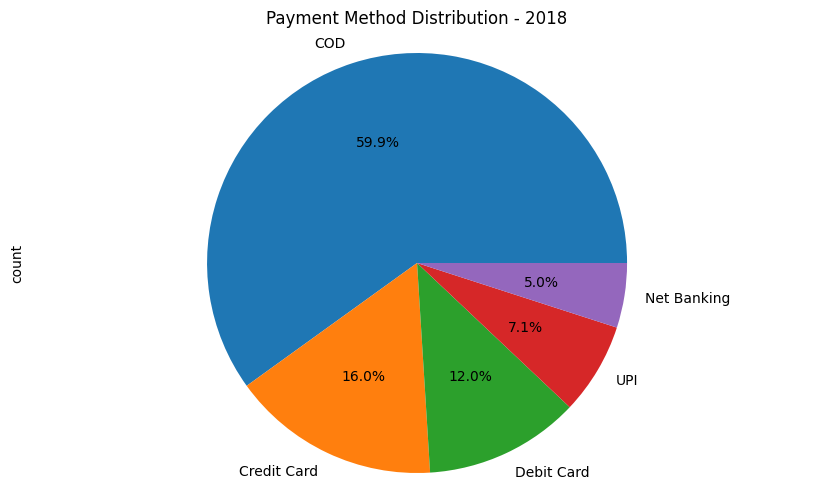

In [ ]:
# Payment Method Distribution
import matplotlib.pyplot as plt

payment_dist = df['payment_method'].value_counts()

plt.figure(figsize=(10, 6))
payment_dist.plot(kind='pie', autopct='%1.1f%%')
plt.title('Payment Method Distribution - 2018')
plt.axis('equal')
plt.show()

In [ ]:
if 'final_amount_inr' in df.columns:
    Q1 = df['final_amount_inr'].quantile(0.25)
    Q3 = df['final_amount_inr'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df['final_amount_inr'] < lower_bound) | (df['final_amount_inr'] > upper_bound)]
    print(f"Number of outliers in final_amount_inr: {len(outliers)}")
    print(f"Outlier percentage: {(len(outliers) / len(df)) * 100:.2f}%")

    if len(outliers) > 0:
        print("simple outlier values:")
        print(outliers['final_amount_inr'].head())

Number of outliers in final_amount_inr: 3958
Outlier percentage: 5.11%
simple outlier values:
25     220178.08
60     330886.71
163    375885.45
164    291656.97
168    275700.83
Name: final_amount_inr, dtype: float64


In [ ]:
import pandas as pd

df=pd.read_csv('amazon_india_2019.csv')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#set display options for better data viewing
pd.set_option('display.max_columns',None)
pd.set_option('display.width', 1000)

print("libraries imported successfully")


libraries imported successfully


In [ ]:
print(f"dataset shape: {df.shape}")

dataset shape: (121605, 34)


In [ ]:
df.head()

,transaction_id,order_date,customer_id,product_id,product_name,category,subcategory,brand,original_price_inr,discount_percent,discounted_price_inr,quantity,subtotal_inr,delivery_charges,final_amount_inr,customer_city,customer_state,customer_tier,customer_spending_tier,customer_age_group,payment_method,delivery_days,delivery_type,is_prime_member,is_festival_sale,festival_name,customer_rating,return_status,order_month,order_year,order_quarter,product_weight_kg,is_prime_eligible,product_rating
0,TXN_2019_00000001,2019-01-05,CUST_2019_00037860,PROD_001930,Fitbit Sports Watch Premium,Electronics,Smart Watch,Fitbit,29122.09,0.00,29122.09,2,58244.18,0.0,58244.18,Kolkata,West Bengal,Metro,Standard,26-35,UPI,5,Standard,False,False,NaN,3.0,Delivered,1,2019,1,0.06,True,3.4
1,TXN_2019_00000002,2019-01-09,CUST_2019_00002481,PROD_001683,Apple Mi Pad 8GB RAM Silver,Electronics,Tablets,Apple,66396.45,0.00,66396.45,1,66396.45,NaN,66396.45,Bangalore,Karnataka,Metro,Standard,18-25,COD,1,Same Day,True,False,NaN,3.5,Delivered,1,2019,1,0.40,True,4.5
2,TXN_2019_00000003,01/02/2019,CUST_2018_00031347,PROD_000460,Oppo F9 64GB Black,Electronics,Smartphones,Oppo,29966.28,0.00,29966.28,1,29966.28,0.0,29966.28,Kolkata,West Bengal,Metro,Standard,18-25,UPI,Same Day,Same Day,True,False,NaN,5.0,Delivered,1,2019,1,0.16,True,3.3
3,TXN_2019_00000004,2019-01-22,CUST_2019_00024783,PROD_000633,Oppo Reno 64GB White,Electronics,Smartphones,Oppo,34225.21,19.68,27490.26,3,82470.78,0.0,82470.78,Lucknow,Uttar Pradesh,Tier1,Budget,26-35,COD,1,Same Day,True,True,Republic Day Sale,4.5,Delivered,1,2019,1,0.20,True,3.3
4,TXN_2019_00000005,2019-01-31,CUST_2019_00018471,PROD_000571,Xiaomi Mi A3 256GB Blue,Electronics,Smartphones,Xiaomi,27092.49,0.00,27092.49,2,54184.98,0.0,54184.98,Kanpur,Uttar Pradesh,Tier1,Budget,46-55,COD,3,Standard,False,False,NaN,NaN,Returned,1,2019,1,0.25,True,4.5


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_percentage.index,
    'Missing_count': df.isnull().sum().values,
    'Missing Percentage': missing_percentage.values,
    }).sort_values('Missing Percentage', ascending=False)
print(missing_df[missing_df['Missing Percentage'] > 0])


                Column  Missing_count  Missing Percentage
25       festival_name          82822           68.107397
26     customer_rating          36793           30.256157
19  customer_age_group          14595           12.001974
13    delivery_charges           9721            7.993915


In [ ]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [ ]:
import numpy as np
numerical_cols = df.select_dtypes(include=[np.number]).columns

In [ ]:
print(f"numerical columns: {numerical_cols.tolist()}")

numerical columns: ['discount_percent', 'discounted_price_inr', 'quantity', 'subtotal_inr', 'delivery_charges', 'final_amount_inr', 'order_month', 'order_year', 'order_quarter', 'product_weight_kg', 'product_rating']


In [ ]:
df[numerical_cols].describe()

,discount_percent,discounted_price_inr,quantity,subtotal_inr,delivery_charges,final_amount_inr,order_month,order_year,order_quarter,product_weight_kg,product_rating
count,121605.000000,121605.000000,121605.000000,121605.000000,111884.0,121605.000000,121605.000000,121605.0,121605.000000,121605.000000,121605.000000
mean,17.726752,56772.118895,1.247112,70769.300522,0.0,70769.300522,7.035772,2019.0,2.681666,0.788817,3.975617
std,20.648307,45033.610117,0.534940,68179.224970,0.0,68179.224970,3.495572,0.0,1.135792,3.680348,0.453629
min,0.000000,933.720000,1.000000,933.720000,0.0,933.720000,1.000000,2019.0,1.000000,0.030000,3.000000
25%,0.000000,24857.360000,1.000000,27082.420000,0.0,27082.420000,4.000000,2019.0,2.000000,0.180000,3.600000
50%,11.150000,39902.110000,1.000000,46692.930000,0.0,46692.930000,7.000000,2019.0,3.000000,0.210000,4.000000
75%,28.850000,79791.670000,1.000000,92729.250000,0.0,92729.250000,10.000000,2019.0,4.000000,0.240000,4.400000
max,70.000000,287334.400000,3.000000,862003.200000,0.0,862003.200000,12.000000,2019.0,4.000000,44.260000,4.800000


In [ ]:
import pandas as pd
df = pd.read_csv('amazon_india_2019.csv')
categorical_cols = df.select_dtypes(include=['object']).columns

In [ ]:
print(categorical_cols.tolist())

['transaction_id', 'order_date', 'customer_id', 'product_id', 'product_name', 'category', 'subcategory', 'brand', 'original_price_inr', 'customer_city', 'customer_state', 'customer_tier', 'customer_spending_tier', 'customer_age_group', 'payment_method', 'delivery_days', 'delivery_type', 'is_prime_member', 'is_festival_sale', 'festival_name', 'customer_rating', 'return_status', 'is_prime_eligible']


In [ ]:
payment_dist = df['payment_method'].value_counts()
payment_percent = (payment_dist / len(df) * 100).round(2)

payment_amalysis = pd.DataFrame({
    'Count': payment_dist,
    'Percentage': payment_percent
})

print(payment_amalysis)

                Count  Percentage
payment_method                   
COD             48696       40.04
UPI             24737       20.34
Credit Card     20571       16.92
Debit Card      19147       15.75
Net Banking      8454        6.95


In [ ]:
import pandas as pd

df = pd.read_csv('amazon_india_2019.csv')
df['order_date'] = pd.to_datetime(df['order_date'] , errors = 'coerce')

In [ ]:
monthly_sales = df.groupby('order_month')['final_amount_inr'].agg(['sum', 'count'])
monthly_sales.columns = ['Total_revenue', 'Order_count']
print(monthly_sales)

             Total_revenue  Order_count
order_month                            
1             6.606865e+08         8854
2             5.632747e+08         7738
3             5.908953e+08         8853
4             7.086215e+08         8839
5             6.435234e+08         9940
6             5.801161e+08         8839
7             6.300419e+08         9948
8             7.111369e+08         8848
9             6.892944e+08         9949
10            8.377219e+08        14374
11            9.231033e+08        12171
12            1.067485e+09        13252


In [ ]:
quarterly_sales = df.groupby('order_quarter')['final_amount_inr'].agg(['sum', 'count'])
quarterly_sales.columns = ['Total_revenue', 'Order_count']
print(quarterly_sales)

               Total_revenue  Order_count
order_quarter                            
1               1.814856e+09        25445
2               1.932261e+09        27618
3               2.030473e+09        28745
4               2.828310e+09        39797


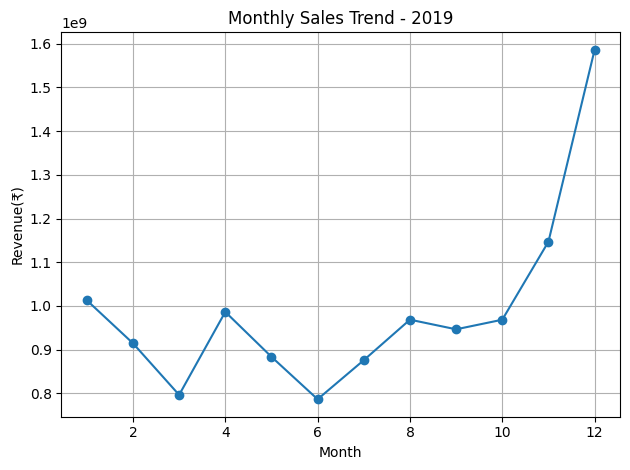

In [ ]:
import matplotlib.pyplot as plt

monthly_sales['Total_revenue'].plot(kind ='line' , marker = 'o')
plt.title('Monthly Sales Trend - 2019')
plt.ylabel('Revenue(₹)')
plt.xlabel('Month')
plt.grid(True)
plt.tight_layout()
plt.show()

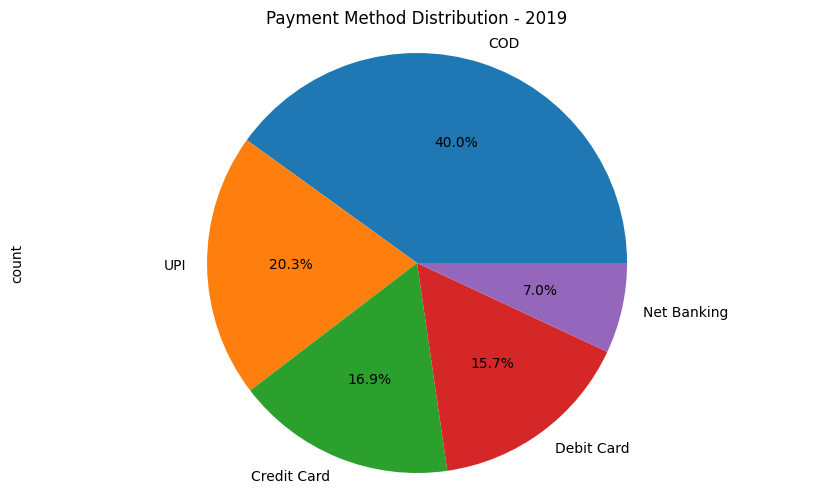

In [ ]:
# Payment Method Distribution
import matplotlib.pyplot as plt

payment_dist = df['payment_method'].value_counts()

plt.figure(figsize=(10, 6))
payment_dist.plot(kind='pie', autopct='%1.1f%%')
plt.title('Payment Method Distribution - 2019')
plt.axis('equal')
plt.show()

In [ ]:
if 'final_amount_inr' in df.columns:
    Q1 = df['final_amount_inr'].quantile(0.25)
    Q3 = df['final_amount_inr'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df['final_amount_inr'] < lower_bound) | (df['final_amount_inr'] > upper_bound)]
    print(f"Number of outliers in final_amount_inr: {len(outliers)}")
    print(f"Outlier percentage: {(len(outliers) / len(df)) * 100:.2f}%")

    if len(outliers) > 0:
        print("simple outlier values:")
        print(outliers['final_amount_inr'].head())

Number of outliers in final_amount_inr: 6911
Outlier percentage: 5.68%
simple outlier values:
11     305514.69
33     273576.51
40     430306.92
49     209887.51
101    194992.56
Name: final_amount_inr, dtype: float64


In [ ]:
import pandas as pd

df=pd.read_csv('amazon_india_2020.csv')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#set display options for better data viewing
pd.set_option('display.max_columns',None)
pd.set_option('display.width', 1000)

print("libraries imported successfully")

libraries imported successfully


In [ ]:
print(f"dataset shape: {df.shape}")

dataset shape: (143715, 34)


In [ ]:
df.head()

,transaction_id,order_date,customer_id,product_id,product_name,category,subcategory,brand,original_price_inr,discount_percent,discounted_price_inr,quantity,subtotal_inr,delivery_charges,final_amount_inr,customer_city,customer_state,customer_tier,customer_spending_tier,customer_age_group,payment_method,delivery_days,delivery_type,is_prime_member,is_festival_sale,festival_name,customer_rating,return_status,order_month,order_year,order_quarter,product_weight_kg,is_prime_eligible,product_rating
0,TXN_2020_00000001,2020-01-19,CUST_2020_00001031,PROD_000402,Xiaomi Poco F1 128GB Blue,Electronics,Smartphones,Xiaomi,36202.67,7.11,33628.52,3,100885.56,0.0,100885.56,Delhi,Delhi,Metro,Standard,55+,UPI,1,Same Day,True,False,NaN,4.5,Cancelled,1,2020,1,0.19,False,3.4
1,TXN_2020_00000002,2020-01-19,CUST_2018_00013266,PROD_000486,Apple iPhone 11 128GB Blue,Electronics,Smartphones,Apple,165163.92,0.00,165163.92,1,165163.92,0.0,165163.92,Ahmedabad,Gujarat,Tier1,Standard,36-45,Net Banking,4,Standard,False,False,NaN,NaN,Returned,1,2020,1,0.19,True,4.3
2,TXN_2020_00000003,2020-01-17,CUST_2020_00001673,PROD_000278,Xiaomi Redmi 4A 16GB White,Electronics,Smartphones,Xiaomi,32906.94,0.00,32906.94,1,32906.94,0.0,32906.94,Chennai,Tamil Nadu,Metro,Standard,36-45,Net Banking,5,Standard,False,False,NaN,5.0,Delivered,1,2020,1,0.21,True,4.1
3,TXN_2020_00000004,2020-01-25,CUST_2020_00026212,PROD_000245,Samsung Galaxy S8+ 32GB Black,Electronics,Smartphones,Samsung,136675.37,45.87,73976.06,1,73976.06,0.0,73976.06,Bhubaneswar,Odisha,Tier2,Premium,18-25,UPI,1,Same Day,True,True,Republic Day Sale,4.5,Delivered,1,2020,1,0.23,True,3.8
4,TXN_2020_00000005,2020-01-01,CUST_2015_00009980,PROD_000765,Vivo V20 64GB Black,Electronics,Smartphones,Vivo,30041.81,0.00,30041.81,1,30041.81,0.0,30041.81,Bangalore,Karnataka,Metro,Standard,46-55,COD,3,Standard,0,False,NaN,4.0,Delivered,1,2020,1,0.23,False,3.9


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_percentage.index,
    'Missing_count': df.isnull().sum().values,
    'Missing Percentage': missing_percentage,
    }).sort_values('Missing Percentage', ascending=False)
print(missing_df[missing_df['Missing Percentage'] > 0])


                                Column  Missing_count  Missing Percentage
festival_name            festival_name          99915           69.523014
customer_rating        customer_rating          43625           30.355217
customer_age_group  customer_age_group          17244           11.998748
delivery_charges      delivery_charges          11518            8.014473


In [ ]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [ ]:
import numpy as np
numerical_cols = df.select_dtypes(include = [np.number]).columns

In [ ]:
print(f"numerical columns: {numerical_cols.tolist()}")

numerical columns: ['discount_percent', 'discounted_price_inr', 'quantity', 'subtotal_inr', 'delivery_charges', 'final_amount_inr', 'order_month', 'order_year', 'order_quarter', 'product_weight_kg', 'product_rating']


In [ ]:
df[numerical_cols].describe()

,discount_percent,discounted_price_inr,quantity,subtotal_inr,delivery_charges,final_amount_inr,order_month,order_year,order_quarter,product_weight_kg,product_rating
count,143715.000000,143715.000000,143715.000000,143715.000000,132197.0,143715.000000,143715.000000,143715.0,143715.000000,143715.000000,143715.000000
mean,17.172842,66135.221996,1.250684,82616.249430,0.0,82616.249430,6.890471,2020.0,2.627186,0.735973,3.979571
std,20.459303,52773.938872,0.535709,79736.783535,0.0,79736.783535,3.561314,0.0,1.143137,3.545194,0.449468
min,0.000000,551.170000,1.000000,598.800000,0.0,598.800000,1.000000,2020.0,1.000000,0.030000,3.000000
25%,0.000000,29371.510000,1.000000,32087.290000,0.0,32087.290000,4.000000,2020.0,2.000000,0.180000,3.600000
50%,9.750000,45954.260000,1.000000,53922.510000,0.0,53922.510000,7.000000,2020.0,3.000000,0.210000,4.000000
75%,28.130000,92326.320000,1.000000,107974.840000,0.0,107974.840000,10.000000,2020.0,4.000000,0.240000,4.400000
max,70.000000,326569.590000,3.000000,979708.770000,0.0,979708.770000,12.000000,2020.0,4.000000,44.260000,4.800000


In [ ]:
import pandas as pd
df = pd.read_csv('amazon_india_2020.csv')
categorical_cols = df.select_dtypes(include=['object']).columns


In [ ]:
monthly_sales = df.groupby('order_month')['final_amount_inr'].agg(['sum', 'count'])
monthly_sales.columns = ['Total_revenue', 'Order_count']
print(monthly_sales)

             Total_revenue  Order_count
order_month                            
1             1.013018e+09        11767
2             9.145839e+08        10454
3             7.964934e+08        10445
4             9.863922e+08        10463
5             8.836448e+08        11769
6             7.865501e+08        10447
7             8.759377e+08        11752
8             9.685912e+08        10435
9             9.465505e+08        11751
10            9.684953e+08        14370
11            1.147016e+09        13072
12            1.585921e+09        16990


In [ ]:
quarterly_sales = df.groupby('order_month')['final_amount_inr'].agg(['sum', 'count'])
quarterly_sales.columns = ['Total_revenue', 'Order_count']
print(quarterly_sales)

             Total_revenue  Order_count
order_month                            
1             1.013018e+09        11767
2             9.145839e+08        10454
3             7.964934e+08        10445
4             9.863922e+08        10463
5             8.836448e+08        11769
6             7.865501e+08        10447
7             8.759377e+08        11752
8             9.685912e+08        10435
9             9.465505e+08        11751
10            9.684953e+08        14370
11            1.147016e+09        13072
12            1.585921e+09        16990


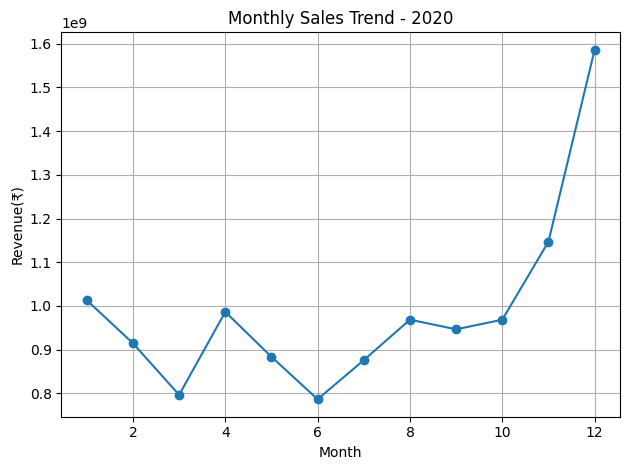

In [ ]:
import matplotlib.pyplot as plt

monthly_sales['Total_revenue'].plot(kind ='line' , marker = 'o')
plt.title('Monthly Sales Trend - 2020')
plt.ylabel('Revenue(₹)')
plt.xlabel('Month')
plt.grid(True)
plt.tight_layout()
plt.show()

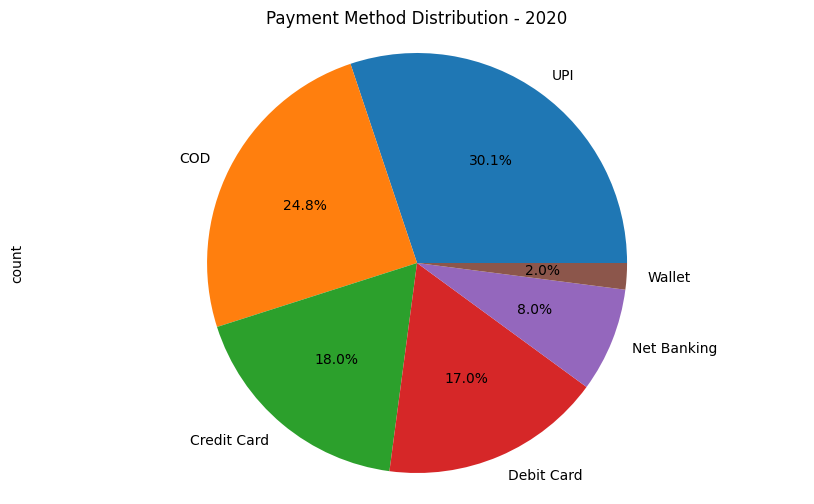

In [ ]:
# Payment Method Distribution
import matplotlib.pyplot as plt

payment_dist = df['payment_method'].value_counts()

plt.figure(figsize=(10, 6))
payment_dist.plot(kind='pie', autopct='%1.1f%%')
plt.title('Payment Method Distribution - 2020')
plt.axis('equal')
plt.show()

In [ ]:
if 'final_amount_inr' in df.columns:
    Q1 = df['final_amount_inr'].quantile(0.25)
    Q3 = df['final_amount_inr'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df['final_amount_inr'] < lower_bound) | (df['final_amount_inr'] > upper_bound)]
    print(f"Number of outliers in final_amount_inr: {len(outliers)}")
    print(f"Outlier percentage: {(len(outliers) / len(df)) * 100:.2f}%")

    if len(outliers) > 0:
        print("simple outlier values:")
        print(outliers['final_amount_inr'].head())

Number of outliers in final_amount_inr: 8423
Outlier percentage: 5.86%
simple outlier values:
20     227743.93
40     274094.96
52     385874.73
67     293591.61
166    223220.72
Name: final_amount_inr, dtype: float64


In [ ]:
import pandas as pd

df=pd.read_csv('amazon_india_2021.csv')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#set display options for data viewing
pd.set_option('display.max_columns',None)
pd.set_option('display.width', 1000)

print("libraries imported successfully")

libraries imported successfully


In [ ]:
print(f"dataset shape: {df.shape}")

dataset shape: (138187, 34)


In [ ]:
print(f"dataset shape: {df.shape}")


dataset shape: (138187, 34)


In [ ]:
df.head()

,transaction_id,order_date,customer_id,product_id,product_name,category,subcategory,brand,original_price_inr,discount_percent,discounted_price_inr,quantity,subtotal_inr,delivery_charges,final_amount_inr,customer_city,customer_state,customer_tier,customer_spending_tier,customer_age_group,payment_method,delivery_days,delivery_type,is_prime_member,is_festival_sale,festival_name,customer_rating,return_status,order_month,order_year,order_quarter,product_weight_kg,is_prime_eligible,product_rating
0,TXN_2021_00000001,2021-01-29,CUST_2021_00014071,PROD_000178,Xiaomi Mi 5 64GB Black,Electronics,Smartphones,Xiaomi,43292.78,22.96,33354.53,1,33354.53,NaN,33354.53,Mumbai,Maharashtra,Metro,Standard,18-25,UPI,1,Same Day,True,False,NaN,4.5,Delivered,1,2021,1,0.24,True,3.7
1,TXN_2021_00000002,2021-01-10,CUST_2019_00006495,PROD_000610,Vivo V15 Pro 256GB White,Electronics,Smartphones,Vivo,32964.72,16.68,27465.37,1,27465.37,0.0,27465.37,Jaipur,Rajasthan,Tier1,Budget,26-35,UPI,5,Standard,False,False,NaN,5.0,Delivered,1,2021,1,0.19,True,4.1
2,TXN_2021_00000003,2021-01-18,CUST_2018_00029239,PROD_000404,Xiaomi Poco F1 128GB Gold,Electronics,Smartphones,Xiaomi,45794.75,0.00,45794.75,2,91589.50,0.0,91589.50,Jaipur,Rajasthan,Tier1,Standard,26-35,COD,5,Standard,False,False,NaN,NaN,Delivered,1,2021,1,0.22,True,4.4
3,TXN_2021_00000004,2021-01-08,CUST_2021_00040991,PROD_000664,Apple iPhone SE (2nd gen) 64GB Gold,Electronics,Smartphones,Apple,136337.08,0.00,136337.08,1,136337.08,0.0,136337.08,Mumbai,Maharashtra,Metro,Premium,26-35,UPI,2,Express,True,False,NaN,4.0,Delivered,1,2021,1,0.17,True,3.8
4,TXN_2021_00000005,2021-01-02,CUST_2016_00006478,PROD_000466,Oppo A3s 64GB Black,Electronics,Smartphones,Oppo,19992.12,0.00,19992.12,1,19992.12,0.0,19992.12,Bareilly,Uttar Pradesh,Rural,Budget,46-55,UPI,4,Standard,False,False,NaN,3.0,Delivered,1,2021,1,0.24,1,3.3


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_percentage.index,
    'Missing_count': df.isnull().sum().values,
    'Missing Percentage': missing_percentage,
    }).sort_values('Missing Percentage', ascending=False)
print(missing_df[missing_df['Missing Percentage'] > 0])


                                Column  Missing_count  Missing Percentage
festival_name            festival_name          95887           69.389306
customer_rating        customer_rating          41885           30.310377
customer_age_group  customer_age_group          16585           12.001853
delivery_charges      delivery_charges          11040            7.989174


In [ ]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [ ]:
import numpy as np
numerical_cols = df.select_dtypes(include = [np.number]).columns

In [ ]:
print(f"numerical columns: {numerical_cols.tolist()}")

numerical columns: ['discount_percent', 'discounted_price_inr', 'quantity', 'subtotal_inr', 'delivery_charges', 'final_amount_inr', 'order_month', 'order_year', 'order_quarter', 'product_weight_kg', 'product_rating']


In [ ]:
df[numerical_cols].describe()

,discount_percent,discounted_price_inr,quantity,subtotal_inr,delivery_charges,final_amount_inr,order_month,order_year,order_quarter,product_weight_kg,product_rating
count,143715.000000,143715.000000,143715.000000,143715.000000,132197.0,143715.000000,143715.000000,143715.0,143715.000000,143715.000000,143715.000000
mean,17.172842,66135.221996,1.250684,82616.249430,0.0,82616.249430,6.890471,2020.0,2.627186,0.735973,3.979571
std,20.459303,52773.938872,0.535709,79736.783535,0.0,79736.783535,3.561314,0.0,1.143137,3.545194,0.449468
min,0.000000,551.170000,1.000000,598.800000,0.0,598.800000,1.000000,2020.0,1.000000,0.030000,3.000000
25%,0.000000,29371.510000,1.000000,32087.290000,0.0,32087.290000,4.000000,2020.0,2.000000,0.180000,3.600000
50%,9.750000,45954.260000,1.000000,53922.510000,0.0,53922.510000,7.000000,2020.0,3.000000,0.210000,4.000000
75%,28.130000,92326.320000,1.000000,107974.840000,0.0,107974.840000,10.000000,2020.0,4.000000,0.240000,4.400000
max,70.000000,326569.590000,3.000000,979708.770000,0.0,979708.770000,12.000000,2020.0,4.000000,44.260000,4.800000


In [ ]:
import pandas as pd
df = pd.read_csv('amazon_india_2020.csv')
categorical_cols = df.select_dtypes(include=['object']).columns


In [ ]:
monthly_sales = df.groupby('order_month')['final_amount_inr'].agg(['sum', 'count'])
monthly_sales.columns = ['Total_revenue', 'Order_count']
print(monthly_sales)

             Total_revenue  Order_count
order_month                            
1             1.013018e+09        11767
2             9.145839e+08        10454
3             7.964934e+08        10445
4             9.863922e+08        10463
5             8.836448e+08        11769
6             7.865501e+08        10447
7             8.759377e+08        11752
8             9.685912e+08        10435
9             9.465505e+08        11751
10            9.684953e+08        14370
11            1.147016e+09        13072
12            1.585921e+09        16990


In [ ]:
quarterly_sales = df.groupby('order_month')['final_amount_inr'].agg(['sum', 'count'])
quarterly_sales.columns = ['Total_revenue', 'Order_count']
print(quarterly_sales)

             Total_revenue  Order_count
order_month                            
1             1.013018e+09        11767
2             9.145839e+08        10454
3             7.964934e+08        10445
4             9.863922e+08        10463
5             8.836448e+08        11769
6             7.865501e+08        10447
7             8.759377e+08        11752
8             9.685912e+08        10435
9             9.465505e+08        11751
10            9.684953e+08        14370
11            1.147016e+09        13072
12            1.585921e+09        16990


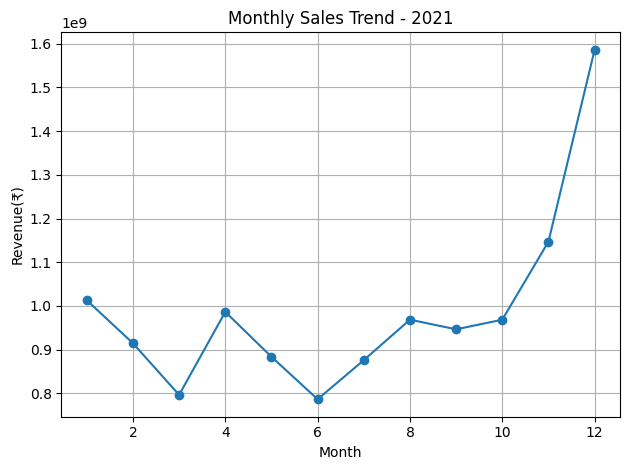

In [ ]:
import matplotlib.pyplot as plt

monthly_sales['Total_revenue'].plot(kind ='line' , marker = 'o')
plt.title('Monthly Sales Trend - 2021')
plt.ylabel('Revenue(₹)')
plt.xlabel('Month')
plt.grid(True)
plt.tight_layout()
plt.show()

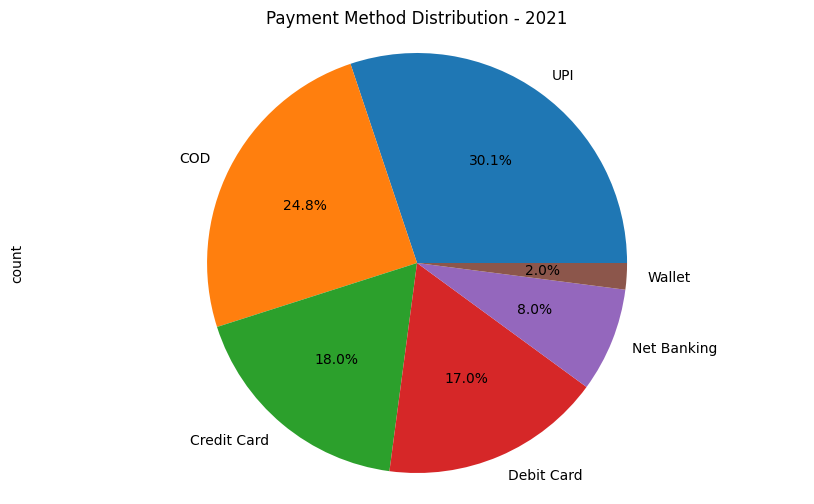

In [ ]:
# Payment Method Distribution
import matplotlib.pyplot as plt

payment_dist = df['payment_method'].value_counts()

plt.figure(figsize=(10, 6))
payment_dist.plot(kind='pie', autopct='%1.1f%%')
plt.title('Payment Method Distribution - 2021')
plt.axis('equal')
plt.show()

In [ ]:
if 'final_amount_inr' in df.columns:
    Q1 = df['final_amount_inr'].quantile(0.25)
    Q3 = df['final_amount_inr'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df['final_amount_inr'] < lower_bound) | (df['final_amount_inr'] > upper_bound)]
    print(f"Number of outliers in final_amount_inr: {len(outliers)}")
    print(f"Outlier percentage: {(len(outliers) / len(df)) * 100:.2f}%")

    if len(outliers) > 0:
        print("simple outlier values:")
        print(outliers['final_amount_inr'].head())

Number of outliers in final_amount_inr: 8423
Outlier percentage: 5.86%
simple outlier values:
20     227743.93
40     274094.96
52     385874.73
67     293591.61
166    223220.72
Name: final_amount_inr, dtype: float64


In [ ]:
import pandas as pd

df=pd.read_csv('amazon_india_2022.csv')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#set option for data viewing
pd.set_option('display.max_columns',None)
pd.set_option('display.width', 1000)

print("libraries imported successfully")

libraries imported successfully


In [ ]:
print(f"dataset shape: {df.shape}")


dataset shape: (132660, 34)


In [ ]:
df.head()

,transaction_id,order_date,customer_id,product_id,product_name,category,subcategory,brand,original_price_inr,discount_percent,discounted_price_inr,quantity,subtotal_inr,delivery_charges,final_amount_inr,customer_city,customer_state,customer_tier,customer_spending_tier,customer_age_group,payment_method,delivery_days,delivery_type,is_prime_member,is_festival_sale,festival_name,customer_rating,return_status,order_month,order_year,order_quarter,product_weight_kg,is_prime_eligible,product_rating
0,TXN_2022_00000001,2022-01-22,CUST_2022_00015913,PROD_000527,Samsung Galaxy A50 64GB White,Electronics,Smartphones,Samsung,26992.07,41.06,15909.72,1,15909.72,0.0,15909.72,Vadodara,Gujarat,Tier2,Standard,26-35,UPI,1,Same Day,True,True,Republic Day Sale,4.0,Delivered,1,2022,1,0.20,0,4.2
1,TXN_2022_00000002,2022-01-11,CUST_2022_00021843,PROD_000979,Samsung Galaxy S22+ 128GB White,Electronics,Smartphones,Samsung,80105.77,0.00,80105.77,1,80105.77,0.0,80105.77,Chennai,Tamil Nadu,Metro,Standard,26-35,Net Banking,2,Express,True,False,NaN,NaN,Delivered,1,2022,1,0.24,False,3.3
2,TXN_2022_00000003,17-01-2022,CUST_2019_00043917,PROD_001909,Xiaomi Fitness Band Deluxe,Electronics,Smart Watch,Xiaomi,27516.92,0.00,27516.92,1,27516.92,0.0,27516.92,Delhi,Delhi,Metro,Standard,26-35,UPI,1,Same Day,True,False,NaN,4.0,Delivered,1,2022,1,0.05,True,4.2
3,TXN_2022_00000004,2022-01-27,CUST_2022_00011696,PROD_000284,Xiaomi Mi A1 32GB White,Electronics,Smartphones,Xiaomi,38018.11,0.00,38018.11,3,114054.33,0.0,114054.33,Delhi,Delhi,Metro,Standard,18-25,UPI,1,Same Day,True,FALSE,NaN,4.0,Delivered,1,2022,1,0.24,True,4.6
4,TXN_2022_00000005,2022-01-16,CUST_2022_00030756,PROD_000556,OnePlus OnePlus 7T 64GB Gold,Electronics,Smartphones,OnePlus,87743.24,0.00,87743.24,1,87743.24,0.0,87743.24,Gorakhpur,Uttar Pradesh,Rural,Premium,18-25,Net Banking,1,Same Day,True,False,NaN,NaN,Delivered,1,2022,1,0.18,True,3.4


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_percentage.index,
    'Missing_count': df.isnull().sum().values,
    'Missing Percentage': missing_percentage,
    }).sort_values('Missing Percentage', ascending=False)
print(missing_df[missing_df['Missing Percentage'] > 0])


                                Column  Missing_count  Missing Percentage
festival_name            festival_name          91868           69.250716
customer_rating        customer_rating          40206           30.307553
customer_age_group  customer_age_group          15917           11.998342
delivery_charges      delivery_charges          10616            8.002412


In [ ]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [ ]:
import numpy as np
numerical_cols = df.select_dtypes(include = [np.number]).columns

In [ ]:
print(f"numerical columns: {numerical_cols.tolist()}")


numerical columns: ['discount_percent', 'discounted_price_inr', 'quantity', 'subtotal_inr', 'delivery_charges', 'final_amount_inr', 'order_month', 'order_year', 'order_quarter', 'product_weight_kg', 'product_rating']


In [ ]:
df[numerical_cols].describe()

,discount_percent,discounted_price_inr,quantity,subtotal_inr,delivery_charges,final_amount_inr,order_month,order_year,order_quarter,product_weight_kg,product_rating
count,132660.000000,132660.000000,132660.000000,1.326600e+05,122044.0,1.326600e+05,132660.000000,132660.0,132660.000000,132660.000000,132660.000000
mean,17.293915,51453.711695,1.249518,6.431714e+04,0.0,6.431714e+04,6.890690,2022.0,2.627175,0.685210,3.967082
std,20.488836,43657.833113,0.535897,6.551933e+04,0.0,6.551933e+04,3.560702,0.0,1.142951,3.218891,0.453197
min,0.000000,353.640000,1.000000,3.536400e+02,0.0,3.936400e+02,1.000000,2022.0,1.000000,0.030000,3.000000
25%,0.000000,22070.560000,1.000000,2.408946e+04,0.0,2.408946e+04,4.000000,2022.0,2.000000,0.180000,3.600000
50%,10.110000,34739.170000,1.000000,4.105539e+04,0.0,4.105539e+04,7.000000,2022.0,3.000000,0.210000,4.000000
75%,28.260000,69820.807500,1.000000,8.231948e+04,0.0,8.231948e+04,10.000000,2022.0,4.000000,0.240000,4.400000
max,70.000000,333716.930000,3.000000,1.001151e+06,0.0,1.001151e+06,12.000000,2022.0,4.000000,44.260000,4.800000


In [ ]:
import pandas as pd
df = pd.read_csv('amazon_india_2022.csv')
categorical_cols = df.select_dtypes(include=['object']).columns

In [ ]:
monthly_sales = df.groupby('order_month')['final_amount_inr'].agg(['sum', 'count'])
monthly_sales.columns = ['Total_revenue', 'Order_count']
print(monthly_sales)

             Total_revenue  Order_count
order_month                            
1             7.238991e+08        10855
2             6.583461e+08         9646
3             5.750871e+08         9645
4             6.918650e+08         9657
5             6.390212e+08        10845
6             5.535118e+08         9658
7             6.283987e+08        10859
8             7.066822e+08         9647
9             6.889096e+08        10855
10            7.032162e+08        13249
11            8.246892e+08        12066
12            1.138686e+09        15678


In [ ]:
quartely_sales = df.groupby('order_quarter')['final_amount_inr'].agg(['sum', 'count'])
monthly_sales.columns = ['Total_revenue', 'Order_count']
print(monthly_sales)

             Total_revenue  Order_count
order_month                            
1             7.238991e+08        10855
2             6.583461e+08         9646
3             5.750871e+08         9645
4             6.918650e+08         9657
5             6.390212e+08        10845
6             5.535118e+08         9658
7             6.283987e+08        10859
8             7.066822e+08         9647
9             6.889096e+08        10855
10            7.032162e+08        13249
11            8.246892e+08        12066
12            1.138686e+09        15678


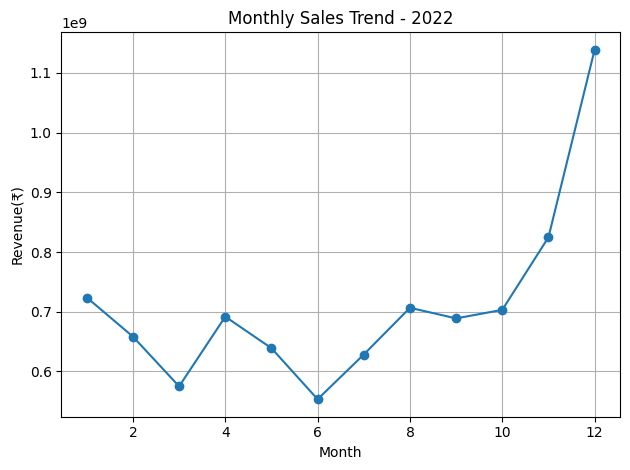

In [ ]:
import matplotlib.pyplot as plt

monthly_sales['Total_revenue'].plot(kind ='line' , marker = 'o')
plt.title('Monthly Sales Trend - 2022')
plt.ylabel('Revenue(₹)')
plt.xlabel('Month')
plt.grid(True)
plt.tight_layout()
plt.show()

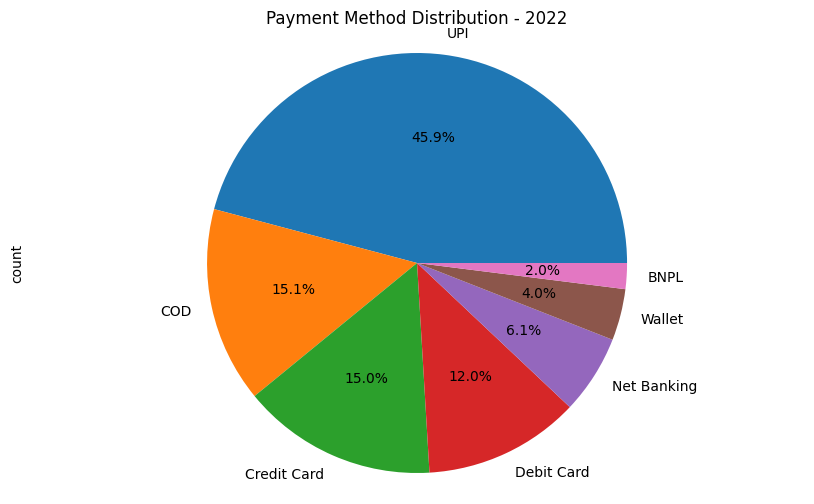

In [ ]:
# Payment Method Distribution
import matplotlib.pyplot as plt

payment_dist = df['payment_method'].value_counts()

plt.figure(figsize=(10, 6))
payment_dist.plot(kind='pie', autopct='%1.1f%%')
plt.title('Payment Method Distribution - 2022')
plt.axis('equal')
plt.show()

In [ ]:
if 'final_amount_inr' in df.columns:
    Q1 = df['final_amount_inr'].quantile(0.25)
    Q3 = df['final_amount_inr'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df['final_amount_inr'] < lower_bound) | (df['final_amount_inr'] > upper_bound)]
    print(f"Number of outliers in final_amount_inr: {len(outliers)}")
    print(f"Outlier percentage: {(len(outliers) / len(df)) * 100:.2f}%")

    if len(outliers) > 0:
        print("simple outlier values:")
        print(outliers['final_amount_inr'].head())

Number of outliers in final_amount_inr: 7985
Outlier percentage: 6.28%
simple outlier values:
4     165637.56
24    388231.48
26    243080.32
27    222069.85
54    223334.32
Name: final_amount_inr, dtype: float64


In [ ]:
import pandas as pd

df=pd.read_csv('amazon_india_2023.csv')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#set option for data viewing
pd.set_option('display.max_columns',None)
pd.set_option('display.width', 1000)

print("libraries imported successfully")


libraries imported successfully


In [ ]:
print(f"dataset shape: {df.shape}")

dataset shape: (127132, 34)


In [ ]:
df.head()

,transaction_id,order_date,customer_id,product_id,product_name,category,subcategory,brand,original_price_inr,discount_percent,discounted_price_inr,quantity,subtotal_inr,delivery_charges,final_amount_inr,customer_city,customer_state,customer_tier,customer_spending_tier,customer_age_group,payment_method,delivery_days,delivery_type,is_prime_member,is_festival_sale,festival_name,customer_rating,return_status,order_month,order_year,order_quarter,product_weight_kg,is_prime_eligible,product_rating
0,TXN_2023_00000001,2023-01-16,CUST_2023_00005822,PROD_001899,Xiaomi Watch Premium,Electronics,Smart Watch,Xiaomi,59416.51,0.00,59416.51,2,118833.02,0.0,118833.02,Kanpur,Uttar Pradesh,Tier1,Standard,26-35,UPI,3,Standard,True,False,NaN,4/5,Returned,1,2023,1,0.06,True,4.2
1,TXN_2023_00000002,2023-01-15,CUST_2019_00019403,PROD_000472,Oppo R17 Pro 64GB Black,Electronics,Smartphones,Oppo,19474.76,0.00,19474.76,1,19474.76,NaN,19474.76,Pune,Maharashtra,Tier1,Standard,26-35,Credit Card,4,Standard,False,False,NaN,4.0,Returned,1,2023,1,0.16,True,3.4
2,TXN_2023_00000003,2023-01-10,CUST_2023_00040022,PROD_001759,JBL Neckband,Electronics,Audio,JBL,27097.23,27.71,19588.64,1,19588.64,0.0,19588.64,Lucknow,Uttar Pradesh,Tier1,Standard,18-25,Net Banking,1,Same Day,True,False,NaN,5.0,Delivered,1,2023,1,0.23,True,3.7
3,TXN_2023_00000004,2023-01-04,CUST_2023_00021818,PROD_001158,Xiaomi Redmi Note 12 256GB White,Electronics,Smartphones,Xiaomi,12883.85,0.00,12883.85,1,12883.85,0.0,12883.85,Chennai,Tamil Nadu,Metro,Budget,18-25,Debit Card,3,Standard,False,False,NaN,3.5,Delivered,1,2023,1,0.23,True,4.1
4,TXN_2023_00000005,2023-01-07,CUST_2020_00048935,PROD_000221,Apple iPhone 8 32GB Blue,Electronics,Smartphones,Apple,165637.56,0.00,165637.56,1,165637.56,NaN,165637.56,Chennai,Tamil Nadu,Metro,Premium,26-35,Credit Card,2,Express,True,False,NaN,3.0,Delivered,1,2023,1,0.22,False,3.5


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_percentage.index,
    'Missing_count': df.isnull().sum().values,
    'Missing Percentage': missing_percentage,
    }).sort_values('Missing Percentage', ascending=False)
print(missing_df[missing_df['Missing Percentage'] > 0])

                                Column  Missing_count  Missing Percentage
festival_name            festival_name          88239           69.407388
customer_rating        customer_rating          38484           30.270900
customer_age_group  customer_age_group          15259           12.002486
delivery_charges      delivery_charges          10162            7.993267


In [ ]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [ ]:
import numpy as np
numerical_cols = df.select_dtypes(include = [np.number]).columns

In [ ]:
print(f"numerical columns: {numerical_cols.tolist()}")


numerical columns: ['discount_percent', 'discounted_price_inr', 'quantity', 'subtotal_inr', 'delivery_charges', 'final_amount_inr', 'order_month', 'order_year', 'order_quarter', 'product_weight_kg', 'product_rating']


In [ ]:
df[numerical_cols].describe()

,discount_percent,discounted_price_inr,quantity,subtotal_inr,delivery_charges,final_amount_inr,order_month,order_year,order_quarter,product_weight_kg,product_rating
count,127132.000000,127132.000000,127132.000000,127132.00000,116970.000000,127132.000000,127132.000000,127132.0,127132.000000,127132.000000,127132.000000
mean,17.307966,48508.519733,1.249552,60669.21739,0.000342,60669.217705,6.891184,2023.0,2.627356,0.731544,3.969024
std,20.551778,41562.680444,0.535284,62696.58232,0.116956,62696.582018,3.560759,0.0,1.142955,3.427270,0.449844
min,0.000000,413.890000,1.000000,448.71000,0.000000,488.710000,1.000000,2023.0,1.000000,0.030000,3.000000
25%,0.000000,20728.970000,1.000000,22638.91750,0.000000,22638.917500,4.000000,2023.0,2.000000,0.180000,3.600000
50%,10.090000,32838.880000,1.000000,38912.06000,0.000000,38912.060000,7.000000,2023.0,3.000000,0.210000,4.000000
75%,28.200000,64714.410000,1.000000,77663.55250,0.000000,77663.552500,10.000000,2023.0,4.000000,0.240000,4.400000
max,70.000000,310541.570000,3.000000,927233.19000,40.000000,927233.190000,12.000000,2023.0,4.000000,44.260000,4.800000


In [ ]:
import pandas as pd
df = pd.read_csv('amazon_india_2023.csv')
categorical_cols = df.select_dtypes(include=['object']).columns

In [ ]:
monthly_sales = df.groupby('order_month')['final_amount_inr'].agg(['sum', 'count'])
monthly_sales.columns = ['Total_revenue', 'Order_count']
print(monthly_sales)

             Total_revenue  Order_count
order_month                            
1             6.508698e+08        10402
2             5.865014e+08         9235
3             5.104242e+08         9246
4             6.381400e+08         9261
5             5.764985e+08        10398
6             5.014123e+08         9245
7             5.626785e+08        10400
8             6.366863e+08         9244
9             6.247405e+08        10406
10            6.285384e+08        12709
11            7.534260e+08        11552
12            1.043083e+09        15034


In [ ]:
quartely_sales = df.groupby('order_quarter')['final_amount_inr'].agg(['sum', 'count'])
quarterly_sales.columns = ['Total_revenue', 'Order_count']
print(quarterly_sales)

             Total_revenue  Order_count
order_month                            
1             1.013018e+09        11767
2             9.145839e+08        10454
3             7.964934e+08        10445
4             9.863922e+08        10463
5             8.836448e+08        11769
6             7.865501e+08        10447
7             8.759377e+08        11752
8             9.685912e+08        10435
9             9.465505e+08        11751
10            9.684953e+08        14370
11            1.147016e+09        13072
12            1.585921e+09        16990


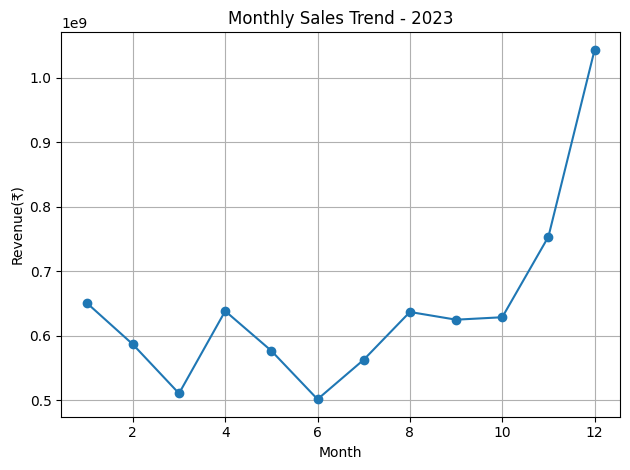

In [ ]:
import matplotlib.pyplot as plt

monthly_sales['Total_revenue'].plot(kind ='line' , marker = 'o')
plt.title('Monthly Sales Trend - 2023')
plt.ylabel('Revenue(₹)')
plt.xlabel('Month')
plt.grid(True)
plt.tight_layout()
plt.show()

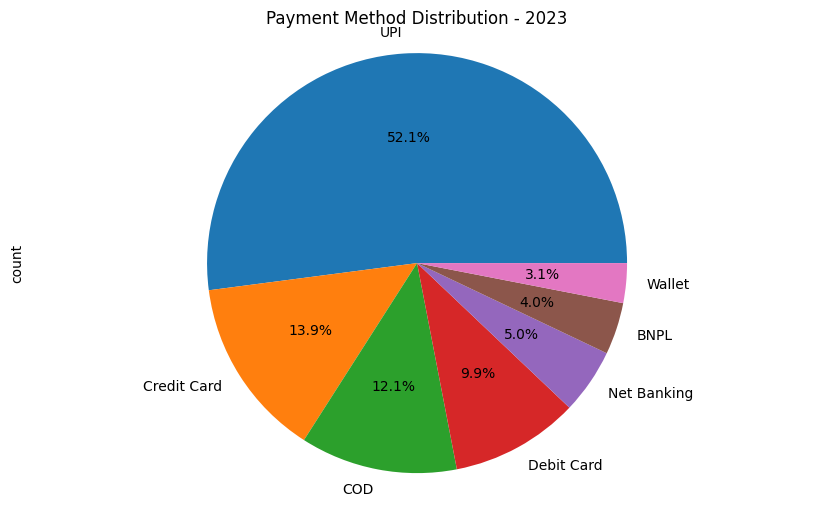

In [ ]:
# Payment Method Distribution
import matplotlib.pyplot as plt

payment_dist = df['payment_method'].value_counts()

plt.figure(figsize=(10, 6))
payment_dist.plot(kind='pie', autopct='%1.1f%%')
plt.title('Payment Method Distribution - 2023')
plt.axis('equal')
plt.show()

In [ ]:
if 'final_amount_inr' in df.columns:
    Q1 = df['final_amount_inr'].quantile(0.25)
    Q3 = df['final_amount_inr'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df['final_amount_inr'] < lower_bound) | (df['final_amount_inr'] > upper_bound)]
    print(f"Number of outliers in final_amount_inr: {len(outliers)}")
    print(f"Outlier percentage: {(len(outliers) / len(df)) * 100:.2f}%")

    if len(outliers) > 0:
        print("simple outlier values:")
        print(outliers['final_amount_inr'].head())

Number of outliers in final_amount_inr: 7985
Outlier percentage: 6.28%
simple outlier values:
4     165637.56
24    388231.48
26    243080.32
27    222069.85
54    223334.32
Name: final_amount_inr, dtype: float64


In [ ]:
import pandas as pd

df=pd.read_csv('amazon_india_2024.csv')


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#set option for dataviewing
pd.set_option('display.max_columns',None)
pd.set_option('display.width', 1000)

print("libraries imported successfully")


libraries imported successfully


In [ ]:
print(f"dataset shape: {df.shape}")

dataset shape: (121605, 34)


In [ ]:
df.head()

,transaction_id,order_date,customer_id,product_id,product_name,category,subcategory,brand,original_price_inr,discount_percent,...,is_festival_sale,festival_name,customer_rating,return_status,order_month,order_year,order_quarter,product_weight_kg,is_prime_eligible,product_rating
0,TXN_2024_00000001,2024-01-03,CUST_2024_00003447,PROD_000387,OnePlus OnePlus 6 64GB White,Electronics,Smartphones,OnePlus,39348.44,0.00,...,False,NaN,NaN,Delivered,1,2024,1,0.24,True,3.4
1,TXN_2024_00000002,2024-01-09,CUST_2018_00008611,PROD_001357,Nothing Phone (2a) Plus 64GB Blue,Electronics,Smartphones,Nothing,"18,694.97",0.00,...,False,NaN,5.0,Delivered,1,2024,1,0.15,True,4.1
2,TXN_2024_00000003,2024-01-09,CUST_2024_00002076,PROD_001899,Xiaomi Watch Premium,Electronics,Smart Watch,Xiaomi,59276.71,17.19,...,False,NaN,NaN,Delivered,1,2024,1,0.06,TRUE,4.2
3,TXN_2024_00000004,2024-01-09,CUST_2024_00014530,PROD_000071,Xiaomi Redmi 2 32GB Black,Electronics,Smartphones,Xiaomi,32605.39,0.00,...,False,NaN,5.0,Delivered,1,2024,1,0.20,True,3.7
4,TXN_2024_00000005,22-01-2024,CUST_2022_00043625,PROD_001144,OnePlus OnePlus 11R 256GB White,Electronics,Smartphones,OnePlus,72805.3,18.89,...,True,Republic Day Sale,4.5,Delivered,1,2024,1,0.21,True,3.6


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_percentage.index,
    'Missing_count': df.isnull().sum().values,
    'Missing Percentage': missing_percentage,
}).sort_values('Missing Percentage', ascending=False)
print(missing_df[missing_df['Missing Percentage'] >0])

                                Column  Missing_count  Missing Percentage
festival_name            festival_name          84110           69.166564
customer_rating        customer_rating          36680           30.163233
customer_age_group  customer_age_group          14601           12.006908
delivery_charges      delivery_charges           9728            7.999671


In [ ]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [ ]:
import numpy as np
numerical_cols = df.select_dtypes(include = [np.number]).columns

In [ ]:
print(f"numerical columns: {numerical_cols.tolist()}")

numerical columns: ['discount_percent', 'discounted_price_inr', 'quantity', 'subtotal_inr', 'delivery_charges', 'final_amount_inr', 'order_month', 'order_year', 'order_quarter', 'product_weight_kg', 'product_rating']


In [ ]:
df[numerical_cols].describe()

,discount_percent,discounted_price_inr,quantity,subtotal_inr,delivery_charges,final_amount_inr,order_month,order_year,order_quarter,product_weight_kg,product_rating
count,121605.000000,121605.000000,121605.000000,121605.000000,111877.000000,121605.000000,121605.000000,121605.0,121605.000000,121605.000000,121605.000000
mean,17.359751,44857.495139,1.250524,56111.287763,0.001073,56111.288750,6.890185,2024.0,2.627137,0.731508,3.971269
std,20.559604,39343.519740,0.537183,58835.293996,0.207132,58835.293063,3.560902,0.0,1.143044,3.472114,0.450561
min,0.000000,344.330000,1.000000,344.330000,0.000000,344.330000,1.000000,2024.0,1.000000,0.030000,3.000000
25%,0.000000,18842.110000,1.000000,20680.650000,0.000000,20680.650000,4.000000,2024.0,2.000000,0.170000,3.600000
50%,10.140000,29781.070000,1.000000,35749.220000,0.000000,35749.220000,7.000000,2024.0,3.000000,0.210000,4.000000
75%,28.360000,59240.740000,1.000000,71213.130000,0.000000,71213.130000,10.000000,2024.0,4.000000,0.240000,4.400000
max,70.000000,281577.970000,3.000000,841923.750000,40.000000,841923.750000,12.000000,2024.0,4.000000,44.260000,4.800000


In [ ]:
import pandas as pd
df = pd.read_csv('amazon_india_2024.csv')
categorical_cols = df.select_dtypes(include=['object']).columns

In [ ]:
monthly_sales = df.groupby('order_month')['final_amount_inr'].agg(['sum', 'count'])
monthly_sales.columns = ( 'Total_revenue',  'Order_count')
print(monthly_sales)

             Total_revenue  Order_count
order_month                            
1             5.794860e+08         9956
2             5.149401e+08         8847
3             4.526567e+08         8841
4             5.599018e+08         8855
5             5.149652e+08         9942
6             4.500106e+08         8836
7             5.007148e+08         9952
8             5.655223e+08         8849
9             5.481084e+08         9948
10            5.497402e+08        12156
11            6.635363e+08        11062
12            9.238309e+08        14361


In [ ]:
quarterly_sales = df.groupby('order_quarter')['final_amount_inr'].agg(['sum', 'count'])
quarterly_sales.columns = ( 'Total_revenue',  'Order_count')
print(quarterly_sales)

               Total_revenue  Order_count
order_quarter                            
1               1.547083e+09        27644
2               1.524878e+09        27633
3               1.614346e+09        28749
4               2.137107e+09        37579


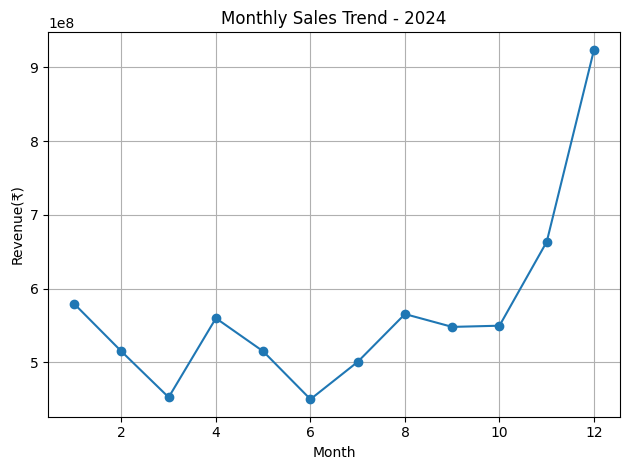

In [ ]:
import matplotlib.pyplot as plt

monthly_sales['Total_revenue'].plot(kind ='line' , marker = 'o')
plt.title('Monthly Sales Trend - 2024')
plt.ylabel('Revenue(₹)')
plt.xlabel('Month')
plt.grid(True)
plt.tight_layout()
plt.show()

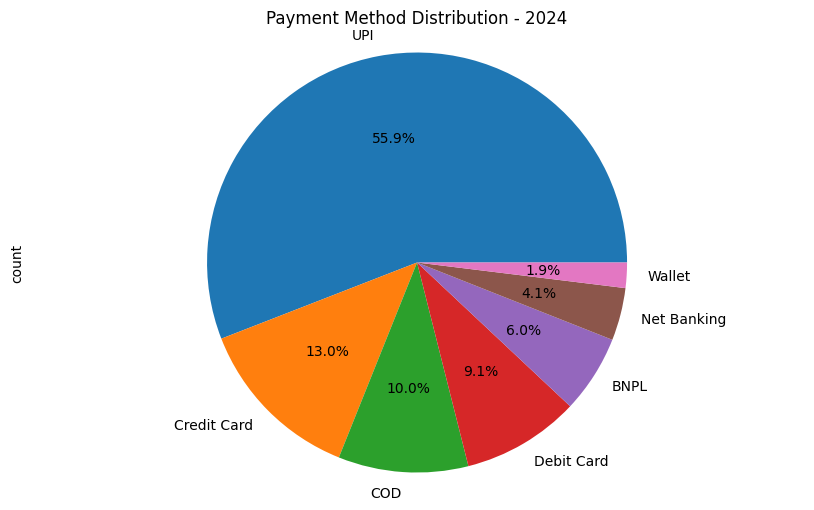

In [ ]:
# Payment Method Distribution
import matplotlib.pyplot as plt

payment_dist = df['payment_method'].value_counts()

plt.figure(figsize=(10, 6))
payment_dist.plot(kind='pie', autopct='%1.1f%%')
plt.title('Payment Method Distribution - 2024')
plt.axis('equal')
plt.show()

In [ ]:
if 'final_amount_inr' in df.columns:
    Q1 = df['final_amount_inr'].quantile(0.25)
    Q3 = df['final_amount_inr'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df['final_amount_inr'] < lower_bound) | (df['final_amount_inr'] > upper_bound)]
    print(f"Number of outliers in final_amount_inr: {len(outliers)}")
    print(f"Outlier percentage: {(len(outliers) / len(df)) * 100:.2f}%")

    if len(outliers) > 0:
        print("simple outlier values:")
        print(outliers['final_amount_inr'].head())

Number of outliers in final_amount_inr: 7825
Outlier percentage: 6.43%
simple outlier values:
15    176411.84
37    225162.62
42    185005.20
44    222284.97
50    368896.47
Name: final_amount_inr, dtype: float64


In [ ]:
import pandas as pd

df=pd.read_csv('amazon_india_2025.csv')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#set option for data viewing
pd.set_option('display.max_columns',None)
pd.set_option('display.width', 1000)

print('libraries imported successfully')

libraries imported successfully


In [ ]:
print(f"dataset shape: {df.shape}")

dataset shape: (77385, 34)


In [ ]:
df.head()

,transaction_id,order_date,customer_id,product_id,product_name,category,subcategory,brand,original_price_inr,discount_percent,discounted_price_inr,quantity,subtotal_inr,delivery_charges,final_amount_inr,customer_city,customer_state,customer_tier,customer_spending_tier,customer_age_group,payment_method,delivery_days,delivery_type,is_prime_member,is_festival_sale,festival_name,customer_rating,return_status,order_month,order_year,order_quarter,product_weight_kg,is_prime_eligible,product_rating
0,TXN_2025_00000001,2025-01-08,CUST_2025_00005600,PROD_000627,Oppo F11 Pro 128GB Black,Electronics,Smartphones,Oppo,10234.12,0.00,10234.12,2,20468.24,0.0,20468.24,Delhi,Delhi,Metro,Budget,NaN,UPI,3,Standard,False,False,NaN,4.5,Delivered,1,2025,1,0.15,True,4.4
1,TXN_2025_00000002,01/15/2025,CUST_2022_00027099,PROD_001699,Samsung Slate 4GB RAM Silver,Electronics,Tablets,Samsung,38241.08,0.00,38241.08,1,38241.08,NaN,38241.08,Hyderabad,Telangana,Metro,Premium,18-25,UPI,2,Express,True,False,NaN,NaN,Returned,1,2025,1,0.64,TRUE,3.4
2,TXN_2025_00000003,2025-01-26,CUST_2021_00027917,PROD_001242,Apple iPhone 16 Plus 64GB Black,Electronics,Smartphones,Apple,121974.26,32.04,82895.16,1,82895.16,0.0,82895.16,Bangalore,Karnataka,Metro,Premium,26-35,UPI,2,Express,True,True,Republic Day Sale,NaN,Returned,1,2025,1,0.18,True,3.4
3,TXN_2025_00000004,2025-01-04,CUST_2025_00004184,PROD_000979,Samsung Galaxy S22+ 128GB White,Electronics,Smartphones,Samsung,59075.7,0.00,59075.70,1,59075.70,0.0,59075.70,Chandigarh,Punjab,Tier2,Standard,46-55,Credit Card,2,Express,True,False,NaN,3.5,Delivered,1,2025,1,0.24,False,3.3
4,TXN_2025_00000005,2025-01-03,CUST_2025_00005205,PROD_001876,Apple Watch Premium,Electronics,Smart Watch,Apple,74269.31,0.00,74269.31,1,74269.31,0.0,74269.31,Kolkata,West Bengal,Metro,Premium,18-25,Credit Card,1,Same Day,True,False,NaN,5.0/5.0,Returned,1,2025,1,0.05,TRUE,4.1


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_percentage.index,
    'Missing_count': df.isnull() .sum().values,
    'Missing Percentage': missing_percentage,
    }).sort_values('Missing Percentage', ascending=False)
print(missing_df[missing_df['Missing Percentage'] > 0])

                                Column  Missing_count  Missing Percentage
festival_name            festival_name          53750           69.457905
customer_rating        customer_rating          23464           30.321122
customer_age_group  customer_age_group           9296           12.012664
delivery_charges      delivery_charges           6196            8.006720


In [ ]:
duplicates_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates_count}")

Number of duplicate rows: 0


In [ ]:
import numpy as np
numerical_cols = df.select_dtypes(include = [np.number]).columns

In [ ]:
print(f"numerical columns: {numerical_cols.tolist()}")

numerical columns: ['discount_percent', 'discounted_price_inr', 'quantity', 'subtotal_inr', 'delivery_charges', 'final_amount_inr', 'order_month', 'order_year', 'order_quarter', 'product_weight_kg', 'product_rating']


In [ ]:
df[numerical_cols].describe()

,discount_percent,discounted_price_inr,quantity,subtotal_inr,delivery_charges,final_amount_inr,order_month,order_year,order_quarter,product_weight_kg,product_rating
count,77385.000000,77385.000000,77385.000000,77385.000000,71189.000000,77385.000000,77385.000000,77385.0,77385.000000,77385.000000,77385.000000
mean,17.303096,39822.206963,1.251535,49772.566849,0.001124,49772.567883,6.891646,2025.0,2.627551,0.695684,3.969382
std,20.483350,35258.985526,0.538055,52100.098932,0.212014,52100.097953,3.560683,0.0,1.142949,3.293547,0.448095
min,0.000000,405.530000,1.000000,405.530000,0.000000,445.530000,1.000000,2025.0,1.000000,0.030000,3.000000
25%,0.000000,16580.040000,1.000000,18334.470000,0.000000,18334.470000,4.000000,2025.0,2.000000,0.170000,3.600000
50%,10.280000,26527.340000,1.000000,31501.730000,0.000000,31501.730000,7.000000,2025.0,3.000000,0.210000,4.000000
75%,28.150000,52418.290000,1.000000,62310.380000,0.000000,62310.380000,10.000000,2025.0,4.000000,0.240000,4.300000
max,70.000000,246106.630000,3.000000,717739.410000,40.000000,717739.410000,12.000000,2025.0,4.000000,44.260000,4.800000


In [ ]:
import pandas as pd
df = pd.read_csv('amazon_india_2025.csv')
categorical_cols = df.select_dtypes(include=['object']).columns


In [ ]:
monthly_sales = df.groupby('order_month')['final_amount_inr'].agg(['sum', 'count'])
monthly_sales.columns = ( 'Total_revenue',  'Order_count')
print(monthly_sales)

             Total_revenue  Order_count
order_month                            
1             3.245718e+08         6331
2             2.936863e+08         5619
3             2.567723e+08         5626
4             3.187948e+08         5637
5             2.925926e+08         6328
6             2.553619e+08         5630
7             2.798780e+08         6333
8             3.228410e+08         5628
9             3.111859e+08         6328
10            3.155934e+08         7740
11            3.656632e+08         7032
12            5.147090e+08         9153


In [ ]:
quarterly_sales = df.groupby('order_quarter')['final_amount_inr'].agg(['sum', 'count'])
quarterly_sales.columns = ( 'Total_revenue',  'Order_count')
print(quarterly_sales)

               Total_revenue  Order_count
order_quarter                            
1               8.750304e+08        17576
2               8.667494e+08        17595
3               9.139048e+08        18289
4               1.195966e+09        23925


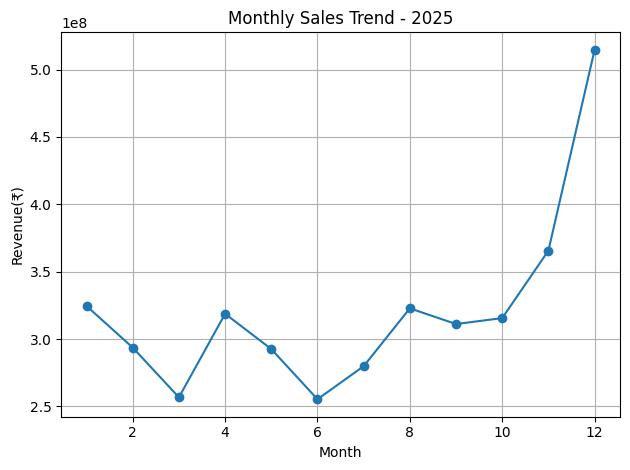

In [ ]:
import matplotlib.pyplot as plt

monthly_sales['Total_revenue'].plot(kind ='line' , marker = 'o')
plt.title('Monthly Sales Trend - 2025')
plt.ylabel('Revenue(₹)')
plt.xlabel('Month')
plt.grid(True)
plt.tight_layout()
plt.show()

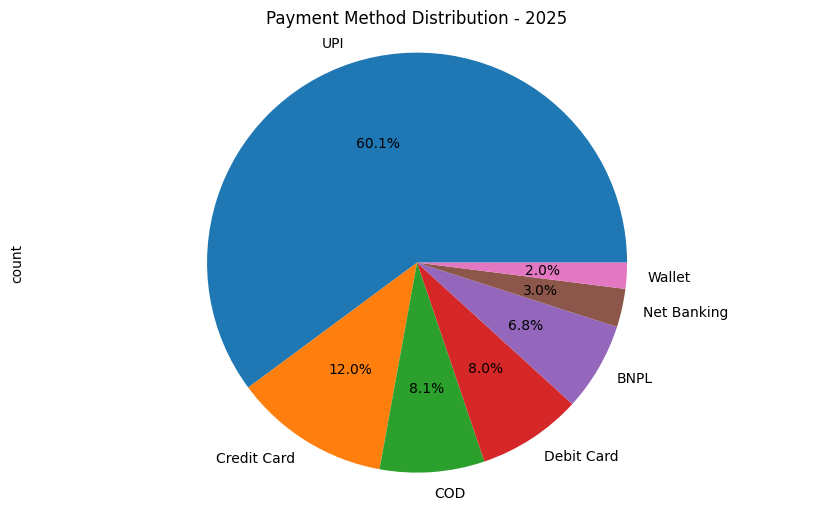

In [ ]:
# Payment Method Distribution
import matplotlib.pyplot as plt

payment_dist = df['payment_method'].value_counts()

plt.figure(figsize=(10, 6))
payment_dist.plot(kind='pie', autopct='%1.1f%%')
plt.title('Payment Method Distribution - 2025')
plt.axis('equal')
plt.show()

In [ ]:
if 'final_amount_inr' in df.columns:
    Q1 = df['final_amount_inr'].quantile(0.25)
    Q3 = df['final_amount_inr'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df['final_amount_inr'] < lower_bound) | (df['final_amount_inr'] > upper_bound)]
    print(f"Number of outliers in final_amount_inr: {len(outliers)}")
    print(f"Outlier percentage: {(len(outliers) / len(df)) * 100:.2f}%")

    if len(outliers) > 0:
        print("simple outlier values:")
        print(outliers['final_amount_inr'].head())

Number of outliers in final_amount_inr: 5182
Outlier percentage: 6.70%
simple outlier values:
8      147882.98
21     164649.47
25     159640.59
42     511818.48
118    380044.04
Name: final_amount_inr, dtype: float64


In [3]:
!pip install streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 116.4 MB/s eta 0:00:00


2026-05-06 05:55:19.930 Uvicorn server started on 0.0.0.0:8501

  Welcome to Streamlit. Check out our demo in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.42.233.51:8501

  Ready to create your own Python apps super quickly?
  Head over to https://docs.streamlit.io

  May you create awesome apps!


  Stopping...
  Stopping...
  Stopping...
  Stopping...
